# First attempts on the highway-env environment

In [1]:
import gymnasium as gym
import pandas as pd
from collections import deque
import highway_env
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from tqdm import tqdm
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG
import imageio
from IPython.display import Image

c:\Users\marti\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Getting familiar with the environment

### First environment

In [2]:
def make_env(render_mode="rgb_array"):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset()
    env = Monitor(env)
    return env

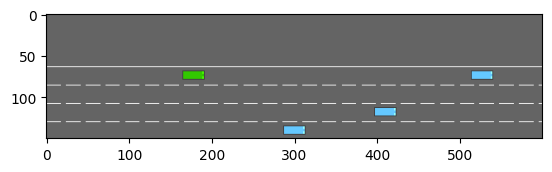

Observation space shape: (10, 5)
Action space: Discrete(5)


: 

In [ ]:
temp_env = make_env()
obs, info = temp_env.reset()

# Visualization
plt.imshow(temp_env.render())
plt.show()
print(f"Observation space shape: {temp_env.observation_space.shape}")
print(f"Action space: {temp_env.action_space}")

### Test with random actions

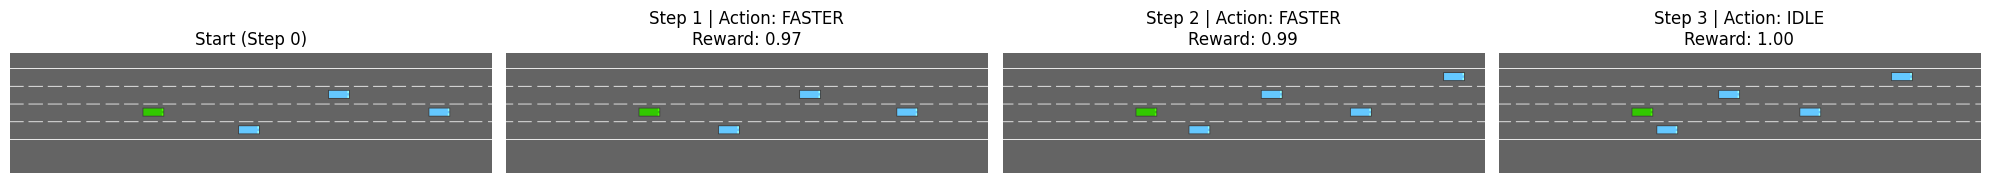

In [17]:
env = make_env(render_mode="rgb_array")

obs, info = env.reset()

# Plotting the start, and the result of 3 actions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot the starting state
axes[0].imshow(env.render())
axes[0].set_title("Start (Step 0)")
axes[0].axis('off')

action_names = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

for step in range(1, 4):
    # We pick a random action
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    # Plot
    axes[step].imshow(env.render())
    title = f"Step {step} | Action: {action_names[action]}\nReward: {reward:.2f}"
    axes[step].set_title(title)
    axes[step].axis('off')
    if terminated or truncated:
        print(f"Episode ended early at step {step}!")
        break
plt.tight_layout()
plt.show()

env.close()

## Defining useful functions

Evaluate an agent: computes the mean and standard deviations of the total rewards.

In [3]:
ACTION_NAMES = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}
N_ACTIONS = len(ACTION_NAMES)

def evaluate_agent(agent, num_episodes=50, seeds=[3, 333, 3333]):
    """
    Evaluates an agent on multiple seeds.
    Returns a list of (seed, metrics_dict, episode_rewards) tuples.

    New in metrics_dict:
      - episode_mean_speeds  : list of length num_episodes — mean ego speed per episode
      - episode_action_counts: list of length num_episodes — np.array of shape (N_ACTIONS,)
                               counting how many times each action was chosen that episode
    These two lists are what you pass directly to the plotting functions.
    """
    print(f"Starting evaluation: {num_episodes} episodes per seed.")
    all_seed_results = []

    for seed in seeds:
        env = make_env()
        episode_rewards  = []
        episode_lengths  = []
        episode_crashed  = []
        episode_mean_speeds   = []  
        episode_action_counts = []   

        for episode in tqdm(range(num_episodes), desc=f"Evaluating Seed {seed}"):
            obs, info = env.reset(seed=seed + episode)
            done         = False
            total_reward = 0
            steps        = 0
            step_speeds  = []                    
            step_actions = []                   

            while not done:
                if hasattr(agent, "predict"):
                    action, _states = agent.predict(obs, deterministic=True)
                else:
                    q_values = agent.get_q(obs)
                    action   = np.argmax(q_values)

                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += reward
                steps        += 1
                done = terminated or truncated

                step_speeds.append(info["speed"])   # NEW — ego speed from info dict
                step_actions.append(int(action))    # NEW — record chosen action

            episode_rewards.append(total_reward)
            episode_lengths.append(steps)
            episode_crashed.append(bool(terminated))

            # NEW — aggregate speed and actions for this episode
            episode_mean_speeds.append(np.mean(step_speeds))

            action_counts = np.zeros(N_ACTIONS, dtype=int)
            for a in step_actions:
                action_counts[a] += 1
            episode_action_counts.append(action_counts)

        env.close()

        # Existing metrics — unchanged
        mean_reward   = np.mean(episode_rewards)
        std_reward    = np.std(episode_rewards)
        min_reward    = np.min(episode_rewards)
        max_reward    = np.max(episode_rewards)
        mean_steps    = np.mean(episode_lengths)
        std_steps     = np.std(episode_lengths)
        min_steps     = np.min(episode_lengths)
        max_steps     = np.max(episode_lengths)
        n_crashes     = sum(episode_crashed)
        crash_rate    = n_crashes / num_episodes * 100
        survival_rate = 100 - crash_rate

        # NEW — aggregate speed and action metrics across all episodes of this seed
        mean_speed = np.mean(episode_mean_speeds)
        # mean_action_counts[a] = average number of times action a was chosen per episode
        mean_action_counts = np.mean(episode_action_counts, axis=0)  # shape (N_ACTIONS,)

        metrics = {
            "mean_reward":    mean_reward,
            "std_reward":     std_reward,
            "min_reward":     min_reward,
            "max_reward":     max_reward,
            "mean_steps":     mean_steps,
            "std_steps":      std_steps,
            "min_steps":      min_steps,
            "max_steps":      max_steps,
            "n_crashes":      n_crashes,
            "crash_rate":     crash_rate,
            "survival_rate":  survival_rate,
            # NEW
            "mean_speed":          mean_speed,
            "mean_action_counts":  mean_action_counts,  
            "episode_mean_speeds": episode_mean_speeds,  
            "episode_action_counts": episode_action_counts,  
        }

        print(f"\n{'='*50}")
        print(f"Seed {seed} — {num_episodes} episodes")
        print(f"{'='*50}")
        print(f"  Reward     : {mean_reward:6.2f} ± {std_reward:.2f}  "
              f"[min: {min_reward:.2f}, max: {max_reward:.2f}]")
        print(f"  Steps      : {mean_steps:6.1f} ± {std_steps:.1f}  "
              f"[min: {min_steps}, max: {max_steps}]")
        print(f"  Crashes    : {n_crashes}/{num_episodes} "
              f"({crash_rate:.1f}% crash rate, {survival_rate:.1f}% survival)")
        # NEW
        print(f"  Mean speed : {mean_speed:.2f} m/s")
        print(f"  Action breakdown (mean counts/episode):")
        for a, name in ACTION_NAMES.items():
            print(f"    {name:<12}: {mean_action_counts[a]:5.1f} steps")
        print()

        all_seed_results.append((seed, metrics, episode_rewards))

    # Aggregate across seeds — unchanged block + new lines
    all_means     = [m["mean_reward"]   for _, m, _ in all_seed_results]
    all_survivals = [m["survival_rate"] for _, m, _ in all_seed_results]
    all_steps     = [m["mean_steps"]    for _, m, _ in all_seed_results]
    all_speeds    = [m["mean_speed"]    for _, m, _ in all_seed_results] 

    print(f"\n{'='*50}")
    print(f"OVERALL ({len(seeds)} seeds)")
    print(f"{'='*50}")
    print(f"  Mean reward    : {np.mean(all_means):.2f} ± {np.std(all_means):.2f}  (std is across seeds)")
    print(f"  Survival rate  : {np.mean(all_survivals):.1f}%")
    print(f"  Mean steps     : {np.mean(all_steps):.1f}")
    print(f"  Mean speed     : {np.mean(all_speeds):.2f} m/s") 

    return all_seed_results

Plot the reward and the loss curves

In [4]:
def plot_training_curves(episode_rewards, episode_losses, episode_lengths=None, epsilon_history=None):
    has_lengths = episode_lengths is not None
    has_epsilon = epsilon_history is not None

    n_plots = 2 + has_lengths + has_epsilon
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    ax_idx = 0

    # Reward curve
    ax = axes[ax_idx]; ax_idx += 1
    ax.plot(episode_rewards, alpha=0.3, color='blue', label='Raw reward')
    if len(episode_rewards) >= 20:
        rolling_mean = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
        rolling_std  = np.array([np.std(episode_rewards[i:i+20]) for i in range(len(episode_rewards)-19)])
        x = range(19, len(episode_rewards))
        ax.plot(x, rolling_mean, color='blue', linewidth=2, label='20-ep Moving Avg')
        ax.fill_between(x, rolling_mean - rolling_std, rolling_mean + rolling_std,
                        alpha=0.2, color='blue', label='\u00b11 std')
    ax.set_title("Training curve: Episode rewards")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total reward")
    ax.legend()

    # Loss curve
    ax = axes[ax_idx]; ax_idx += 1
    ax.plot(episode_losses, color='orange', alpha=0.8)
    ax.set_title("Training curve: Mean loss per episode")
    ax.set_xlabel("Episode")
    ax.set_ylabel("MSE loss")

    # Steps per episode
    if has_lengths:
        ax = axes[ax_idx]; ax_idx += 1
        ax.plot(episode_lengths, alpha=0.3, color='green', label='Steps')
        if len(episode_lengths) >= 20:
            rolling_len = np.convolve(episode_lengths, np.ones(20)/20, mode='valid')
            ax.plot(range(19, len(episode_lengths)), rolling_len,
                    color='green', linewidth=2, label='20-ep Moving Avg')
        ax.set_title("Steps per episode (survival time)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Steps")
        ax.legend()

    # Epsilon decay
    if has_epsilon:
        ax = axes[ax_idx]; ax_idx += 1
        ax.plot(epsilon_history, color='red', linewidth=1.5)
        ax.set_title("Epsilon (exploration rate)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Epsilon")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

Record and display a rollout

In [5]:
def record_display_rollout(agent, seed, name_dir=".", name_gif="agent_rollout"):
    env_record = make_env(render_mode="rgb_array")
    obs, info = env_record.reset(seed=seed)
    frames = []
    done = False
    step_count = 0
    print(f"Recording rollout")

    while not done:
        # Capture the visual frame
        frame = env_record.render()
        frames.append(frame)
        if hasattr(agent, "predict"):
            # logic for Stable-Baselines3 model
            action, _ = agent.predict(obs, deterministic=True)
        else:
            # logic for custom DQN/DDQN
            q_values = agent.get_q(obs)
            action = np.argmax(q_values)
        # Take the action
        obs, reward, terminated, truncated, info = env_record.step(action)
        done = terminated or truncated
        step_count += 1
    env_record.close()

    gif_path = f"{name_dir}/{name_gif}_seed{seed}.gif"
    imageio.mimsave(gif_path, frames, fps=15)
    print(f"Episode finished after {step_count} steps.")
    # Display the GIF
    return Image(open(gif_path, 'rb').read())

Train agent (custom agent, not SB3)

In [21]:
def train_agent(agent, env, n_episodes=500):
    episode_rewards, episode_losses, episode_lengths, epsilon_history = [], [], [], []
    episode_mean_q, episode_true_returns = [], []

    for episode in tqdm(range(n_episodes), desc="Training agent"):
        state, _ = env.reset()
        done = False
        total_reward, step_count = 0, 0
        ep_losses, ep_q_values, ep_rewards = [], [], []

        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            result = agent.update(state, action, reward, terminated, truncated, next_state)
            if result[0] != np.inf:
                ep_losses.append(result[0])

            # Compute Q on the ACTUAL current state, not a random batch
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
                q_val = agent.q_net(state_tensor).max(1)[0].item()
            ep_q_values.append(q_val)         
            ep_rewards.append(reward)
            state = next_state
            total_reward += reward
            step_count += 1

        # True discounted return from t=0
        true_return = 0
        for r in reversed(ep_rewards):
            true_return = r + agent.gamma * true_return

        episode_rewards.append(total_reward)
        episode_lengths.append(step_count)
        epsilon_history.append(agent.epsilon)
        episode_true_returns.append(true_return)                         
        episode_mean_q.append(np.mean(ep_q_values) if ep_q_values else 0) 
        episode_losses.append(np.mean(ep_losses) if ep_losses else 0.0)

    return agent, episode_rewards, episode_losses, episode_lengths, epsilon_history, episode_mean_q, episode_true_returns

## Implementing models

### 1. Implement the Stable-Baselines3 baseline model

#### 1.1 - Train the SB3 baseline model

In [31]:
env_sb3 = make_env()

print("Initializing SB3 DQN")

model_sb3 = SB3_DQN(
    policy="MlpPolicy",
    env=env_sb3,
    learning_rate=5e-4,
    buffer_size=15000,
    learning_starts=200,
    batch_size=32,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=50,
    exploration_fraction=0.7,
    verbose=1
)

print("Starting training")

model_sb3.learn(total_timesteps=40000)
model_sb3.save("dqn_sb3_highway")

print("SB3 Baseline training complete and model saved")

Initializing SB3 DQN
Using cpu device
Wrapping the env in a DummyVecEnv.
Starting training
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 17.2     |
|    ep_rew_mean      | 12.7     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3        |
|    time_elapsed     | 18       |
|    total_timesteps  | 69       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.1     |
|    ep_rew_mean      | 12       |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3        |
|    time_elapsed     | 35       |
|    total_timesteps  | 129      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 15.3     |
|    ep_rew_mean      | 11.4     |

#### 1.2 - Evaluate the SB3 baseline model

In [32]:
from stable_baselines3 import DQN as SB3_DQN

model_sb3 = SB3_DQN.load("dqn_sb3_highway")
sb3_results = evaluate_agent(model_sb3, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [06:17<00:00,  7.55s/it]



Seed 3 — 50 episodes
  Reward     :  18.82 ± 5.39  [min: 1.92, max: 23.39]
  Steps      :   26.6 ± 7.9  [min: 3, max: 30]
  Crashes    : 8/50 (16.0% crash rate, 84.0% survival)



Evaluating Seed 333: 100%|██████████| 50/50 [06:37<00:00,  7.95s/it]



Seed 333 — 50 episodes
  Reward     :  20.33 ± 3.37  [min: 3.49, max: 23.55]
  Steps      :   28.8 ± 4.5  [min: 6, max: 30]
  Crashes    : 4/50 (8.0% crash rate, 92.0% survival)



Evaluating Seed 3333: 100%|██████████| 50/50 [06:22<00:00,  7.65s/it]


Seed 3333 — 50 episodes
  Reward     :  19.77 ± 4.68  [min: 1.96, max: 24.88]
  Steps      :   27.6 ± 6.8  [min: 3, max: 30]
  Crashes    : 7/50 (14.0% crash rate, 86.0% survival)


OVERALL (3 seeds)
  Mean reward    : 19.64 ± 0.62  (std is across seeds)
  Survival rate  : 87.3%
  Mean steps     : 27.7


### 2. Implement a Deep Q-Network (DQN)

#### 2.1 - Replay Buffer

In [38]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = [] # stores the transitions
        self.position = 0 # tells us where to insert the next transition

    def push(self, state, action, reward, terminated, next_state):
        """Saves a transition"""
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        # Here we overwrite the oldest memory (transition) with the new one
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """Pick a random batch of transitions, that will be used to train the model"""
        return random.sample(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)

#### 2.2 - Neural Network

In [39]:
class Net(nn.Module):
    def __init__(self, obs_shape, hidden_size, n_actions):
        super(Net, self).__init__()
        # As we have 10 cars and 5 features per car, we use 50 input neurons
        flattened_size = obs_shape[0] * obs_shape[1]
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions) # returns the 5 Q values (one for each action)
        )
    def forward(self, x):
        return self.net(x)

#### 2.3 - Agent

In [42]:
class CustomDQNAgent:
    def __init__(self, action_space, observation_space, decrease_epsilon_factor=2000):
        self.action_space = action_space
        self.observation_space = observation_space
        # Hyperparameters
        self.learning_rate = 5e-4
        self.gamma = 0.99 # Discount factor
        self.batch_size = 32
        self.buffer_capacity = 15000 # Memory size
        self.update_target_every = 50
        # Exploration parameters
        self.epsilon_start = 0.9 # Start here because it will change: we will decrease it
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon = self.epsilon_start

        # Initialization
        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128

        # Define the Deep Q-network and the target network
        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        # We ensure that they have the same weight at the beginning
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()

        self.n_steps = 0 # Total steps
        self.n_eps = 0 # Total episodes

    def get_q(self, state):
        """Get the Q values of the given state by using the network"""
        # Convert numpy state to PyTorch tensor
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]

    def get_action(self, state):
        """Chooses an action using the epsilon-greedyfication"""
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            q_values = self.get_q(state)
            return np.argmax(q_values)

    def decrease_epsilon(self):
        """Gradually reduces the chance of taking random actions over time"""
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor) )

    def update(self, state, action, reward, terminated, truncated, next_state):
        """Stores the transition and performs one step of gradient descent"""

        # Store the transition in the Replay Buffer
        # Convert the inputs to tensors
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0),
            torch.tensor([[action]], dtype=torch.int64),
            torch.tensor([reward], dtype=torch.float32),
            torch.tensor([terminated], dtype=torch.int64),
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        # Check that we have enough data to train
        if len(self.buffer) < self.batch_size:
            return np.inf, np.inf

        # Sample a batch
        transitions = self.buffer.sample(self.batch_size)

        # Transpose the batch
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        # Compute current Q-values
        q_values = self.q_net(state_batch).gather(1, action_batch)

        # Compute target Q-values (Bellman equation)
        with torch.no_grad():
            # Get the max Q-value for the next states from the target network
            next_state_values = self.target_net(next_state_batch).max(1)[0]
            # If the state was terminal, there is no future reward, so we multiply by (1 - terminated_batch)
            next_state_values = next_state_values * (1 - terminated_batch)
            # Compute the expected Q values
            targets = reward_batch + (self.gamma * next_state_values)

        # Compute loss and backpropagate
        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network if necessary
        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.n_steps += 1
        if terminated or truncated:
            self.n_eps += 1
            self.decrease_epsilon()
        mean_max_q = self.q_net(state_batch).max(1)[0].detach().mean().item()
        return loss.item(), mean_max_q

#### 2.4 - Train the DQN model

In [67]:
# Train a DQN agent using the function
N_EPISODES = 500
env = make_env()
dqn_agent = CustomDQNAgent(env.action_space, env.observation_space, 2000)
trained_dqn_agent, dqn_rewards, dqn_losses, dqn_lengths, dqn_epsilons, dqn_mean_q, dqn_true_returns = train_agent(dqn_agent, env, n_episodes=N_EPISODES)

Training agent: 100%|██████████| 500/500 [1:33:15<00:00, 11.19s/it]


Save model

In [68]:
file_path = f"./models/{N_EPISODES}_trained_dqn_highway.pth"
torch.save(trained_dqn_agent.q_net.state_dict(), file_path)
np.save(f"./models/{N_EPISODES}_dqn_rewards.npy", dqn_rewards)
np.save(f"./models/{N_EPISODES}_dqn_losses.npy", dqn_losses)
np.save(f"./models/{N_EPISODES}_dqn_lengths.npy", dqn_lengths)
np.save(f"./models/{N_EPISODES}_dqn_epsilons.npy", dqn_epsilons)
np.save(f"./models/{N_EPISODES}_dqn_mean_q.npy", dqn_mean_q)
np.save(f"./models/{N_EPISODES}_dqn_true_returns.npy", dqn_true_returns)

#### 2.5 Plot the training curves

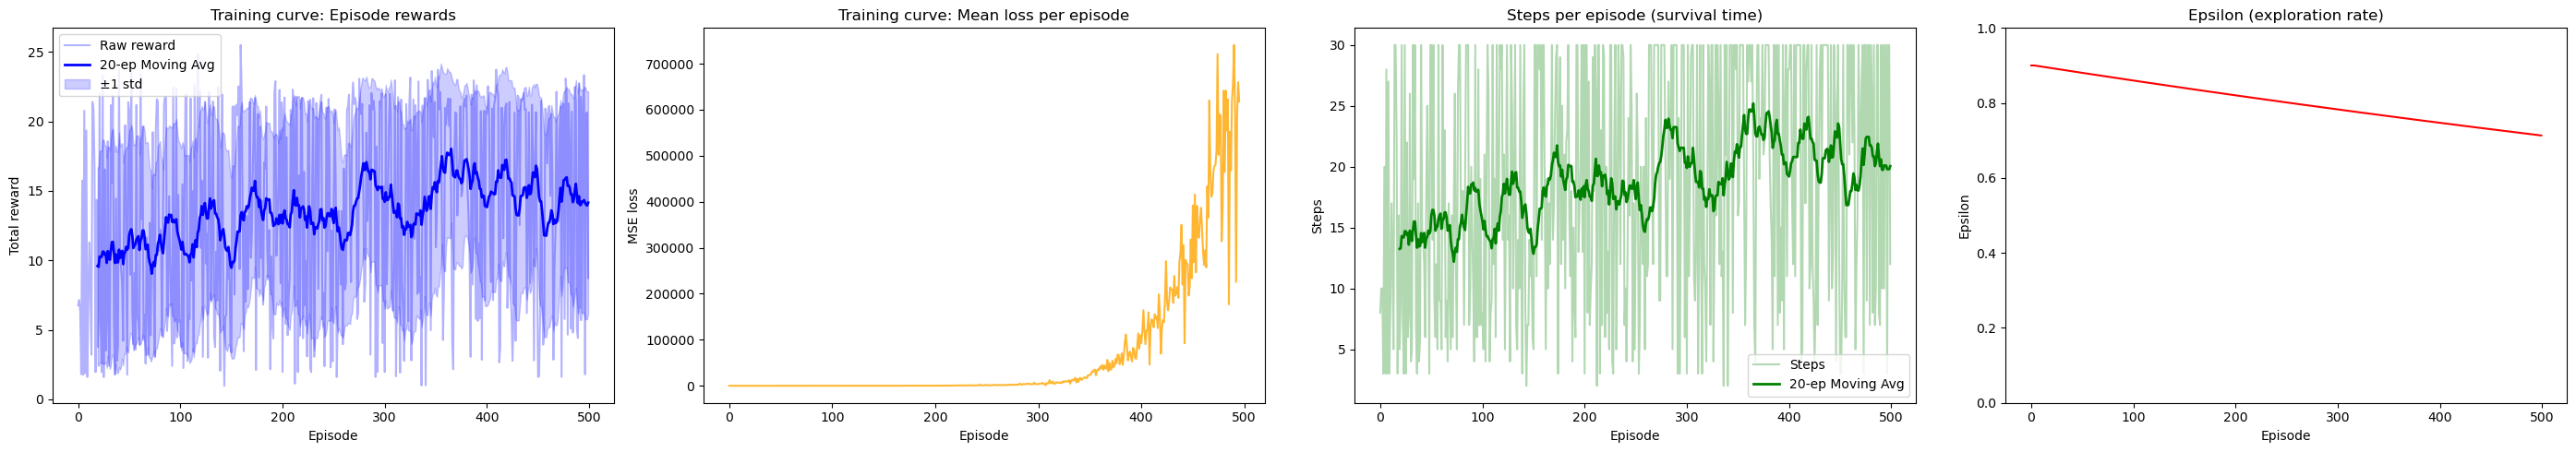

In [69]:
plot_training_curves(dqn_rewards, dqn_losses, dqn_lengths, dqn_epsilons)

#### 2.6 - Evaluate the DQN model

In [70]:
dqn_results = evaluate_agent(trained_dqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [14:02<00:00, 16.86s/it]



Seed 3 — 50 episodes
  Reward     :  20.46 ± 0.02  [min: 20.45, max: 20.57]
  Steps      :   30.0 ± 0.0  [min: 30, max: 30]
  Crashes    : 0/50 (0.0% crash rate, 100.0% survival)



Evaluating Seed 333: 100%|██████████| 50/50 [14:09<00:00, 17.00s/it]



Seed 333 — 50 episodes
  Reward     :  19.79 ± 2.82  [min: 4.09, max: 20.45]
  Steps      :   29.1 ± 3.9  [min: 7, max: 30]
  Crashes    : 3/50 (6.0% crash rate, 94.0% survival)



Evaluating Seed 3333: 100%|██████████| 50/50 [14:49<00:00, 17.80s/it]


Seed 3333 — 50 episodes
  Reward     :  20.42 ± 0.29  [min: 18.41, max: 20.57]
  Steps      :   30.0 ± 0.3  [min: 28, max: 30]
  Crashes    : 1/50 (2.0% crash rate, 98.0% survival)


OVERALL (3 seeds)
  Mean reward    : 20.22 ± 0.31  (std is across seeds)
  Survival rate  : 97.3%
  Mean steps     : 29.7


#### 2.7 - Record a rollout

Recording rollout
Episode finished after 30 steps.


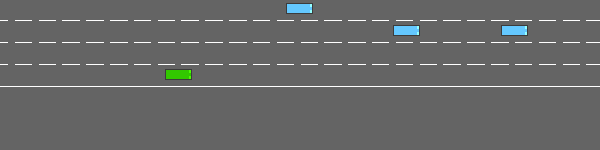

In [71]:
record_display_rollout(agent=trained_dqn_agent, seed=3, name_dir=".", name_gif="dqn_agent_rollout")

#### 2.8 Training on 2000 episodes

In [72]:
# Train a DQN agent using the function
# N_EPISODES = 2000
# env = make_env()
# dqn_agent = CustomDQNAgent(env.action_space, env.observation_space, 8000)
# trained_dqn_agent, dqn_rewards, dqn_losses, dqn_lengths, dqn_epsilons = train_agent(dqn_agent, env, n_episodes=N_EPISODES)

# file_path = "./models/2000_trained_dqn_highway.pth"
# torch.save(trained_dqn_agent.q_net.state_dict(), file_path)
# np.save("./models/2000_dqn_rewards.npy", dqn_rewards)
# np.save("./models/2000_dqn_losses.npy", dqn_losses)
# np.save("./models/2000_dqn_lengths.npy", dqn_lengths)
# np.save("./models/2000_dqn_epsilons.npy", dqn_epsilons)

### 3. Implement a DDQN: DQN with double Q-learning

This DDQN agent is very similar to the DQN one. The only change I made lies in the update function. More particularly, in the way the target used in the loss function is computed: here, we first find the actions that maximize the Q-values in the next state in the main network, then we update using the Q-values in the next state for these actions in the target network. The goal is to decouple selection of the actions from evaluation of the Q-values to fix the overestimation bias.

This is an adaptation of the double Q-learning method mentioned in class, where we have two separate networks Q1 or Q2, and update one of them randomly at each step. Instead, we use the main and the target networks that we already have: the main network acts like Q1 and the target network acts like Q2, but we always pick the action using the main network and evaluate it using the target one.

This idea comes from the double Q-learning adaptation to DQN proposed by van Hasselt et al [https://arxiv.org/abs/1509.06461].

#### 3.1 - Agent

In [73]:
class CustomDDQNAgent:
    def __init__(self, action_space, observation_space, decrease_epsilon_factor=2000):
        self.action_space = action_space
        self.observation_space = observation_space
        # Hyperparameters
        self.learning_rate = 5e-4
        self.gamma = 0.99 # Discount factor
        self.batch_size = 32
        self.buffer_capacity = 15000 # Memory size
        self.update_target_every = 50
        # Exploration parameters
        self.epsilon_start = 0.9 # Start here because it will change: we will decrease it
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon = self.epsilon_start

        # Initialization
        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128

        # Define the Deep Q-network and the target network
        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        # We ensure that they have the same weight at the beginning
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()

        self.n_steps = 0 # Total steps
        self.n_eps = 0 # Total episodes

    def get_q(self, state):
        """Get the Q values of the given state by using the network"""
        # Convert numpy state to PyTorch tensor
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]

    def get_action(self, state):
        """Chooses an action using the epsilon-greedyfication"""
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            q_values = self.get_q(state)
            return np.argmax(q_values)

    def decrease_epsilon(self):
        """Gradually reduces the chance of taking random actions over time"""
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor) )

    def update(self, state, action, reward, terminated, truncated, next_state):
        """Stores the transition and performs one step of gradient descent"""

        # Store the transition in the Replay Buffer
        # Convert the inputs to tensors
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0),
            torch.tensor([[action]], dtype=torch.int64),
            torch.tensor([reward], dtype=torch.float32),
            torch.tensor([terminated], dtype=torch.int64),
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        # Check that we have enough data to train
        if len(self.buffer) < self.batch_size:
            return np.inf, np.inf

        # Sample a batch
        transitions = self.buffer.sample(self.batch_size)

        # Transpose the batch
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        # Compute current Q-values
        q_values = self.q_net(state_batch).gather(1, action_batch)

        # Compute target Q-values (Bellman equation)
        with torch.no_grad():
            # Here lies the difference with the "simple" DQN: first, we find the actions
            # that maximize the Q-values in the next state in the main network ; then,
            # we update using the Q-values in the next state for these actions in the target network
            next_state_indices_main = self.q_net(next_state_batch).argmax(dim=1, keepdim=True)
            next_state_values_target = self.target_net(next_state_batch).gather(1, next_state_indices_main).squeeze(1)
            # Then, same as in DQN
            next_state_values_target = next_state_values_target * (1 - terminated_batch)
            targets = reward_batch + (self.gamma * next_state_values_target)

        # Compute loss and backpropagate
        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network if necessary
        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.n_steps += 1
        if terminated or truncated:
            self.n_eps += 1
            self.decrease_epsilon()
        mean_max_q = self.q_net(state_batch).max(1)[0].detach().mean().item()
        return loss.item(), mean_max_q

#### 3.2 Train the DDQN model

In [74]:
N_EPISODES = 500
env = make_env()
ddqn_agent = CustomDDQNAgent(env.action_space, env.observation_space, 2000)
trained_ddqn_agent, ddqn_rewards, ddqn_losses, ddqn_lengths, ddqn_epsilons, ddqn_mean_q, ddqn_true_returns = train_agent(ddqn_agent, env, n_episodes=N_EPISODES)

Training agent: 100%|██████████| 500/500 [1:13:40<00:00,  8.84s/it]


Save the model

In [75]:
file_path = "./models/500_trained_ddqn_highway.pth"
torch.save(trained_ddqn_agent.q_net.state_dict(), file_path)

np.save(f"./models/{N_EPISODES}_ddqn_rewards.npy", ddqn_rewards)
np.save(f"./models/{N_EPISODES}_ddqn_losses.npy", ddqn_losses)
np.save(f"./models/{N_EPISODES}_ddqn_lengths.npy", ddqn_lengths)
np.save(f"./models/{N_EPISODES}_ddqn_epsilons.npy", ddqn_epsilons)
np.save(f"./models/{N_EPISODES}_ddqn_mean_q.npy", ddqn_mean_q)
np.save(f"./models/{N_EPISODES}_ddqn_true_returns.npy", ddqn_true_returns)

#### 3.3 Evaluate the DDQN model

In [76]:
ddqn_results = evaluate_agent(trained_ddqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [07:02<00:00,  8.45s/it]



Seed 3 — 50 episodes
  Reward     :  20.47 ± 0.04  [min: 20.45, max: 20.57]
  Steps      :   30.0 ± 0.0  [min: 30, max: 30]
  Crashes    : 0/50 (0.0% crash rate, 100.0% survival)



Evaluating Seed 333: 100%|██████████| 50/50 [06:49<00:00,  8.19s/it]



Seed 333 — 50 episodes
  Reward     :  19.94 ± 2.68  [min: 4.09, max: 20.69]
  Steps      :   29.3 ± 3.7  [min: 7, max: 30]
  Crashes    : 2/50 (4.0% crash rate, 96.0% survival)



Evaluating Seed 3333: 100%|██████████| 50/50 [06:46<00:00,  8.13s/it]


Seed 3333 — 50 episodes
  Reward     :  19.91 ± 2.80  [min: 2.73, max: 20.57]
  Steps      :   29.2 ± 3.9  [min: 5, max: 30]
  Crashes    : 2/50 (4.0% crash rate, 96.0% survival)


OVERALL (3 seeds)
  Mean reward    : 20.11 ± 0.26  (std is across seeds)
  Survival rate  : 97.3%
  Mean steps     : 29.5


#### 3.4 Plot the training curves

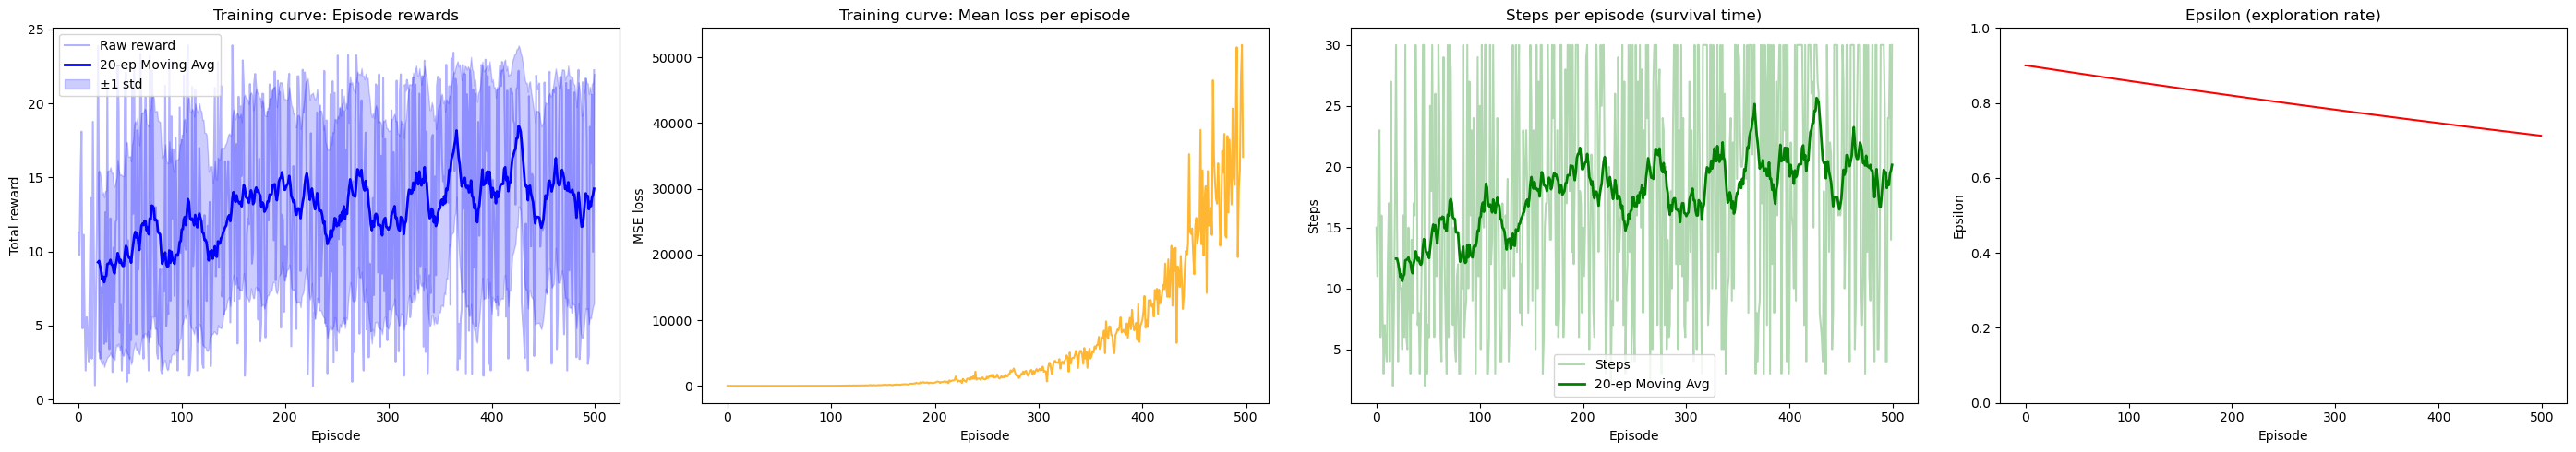

In [77]:
plot_training_curves(ddqn_rewards, ddqn_losses, ddqn_lengths, ddqn_epsilons)

#### 3.5 Record rollout

Recording rollout
Episode finished after 30 steps.


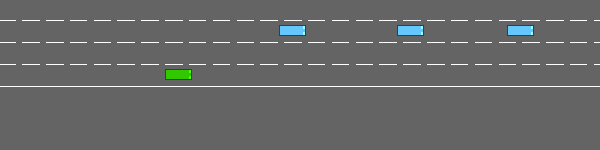

In [78]:
record_display_rollout(agent=trained_ddqn_agent, seed=33, name_dir=".", name_gif="ddqn_agent_rollout")

#### 3.6 Training on 2000 episodes

In [79]:
#N_EPISODES = 2000
#env = make_env()
#ddqn_agent = CustomDDQNAgent(env.action_space, env.observation_space, 8000)
#trained_ddqn_agent, ddqn_rewards, ddqn_losses, ddqn_lengths, ddqn_epsilons = train_agent(ddqn_agent, env, n_episodes=N_EPISODES)

#file_path = "./models/2000_trained_ddqn_highway.pth"
#torch.save(trained_ddqn_agent.q_net.state_dict(), file_path)
#np.save("./models/2000_ddqn_rewards.npy", ddqn_rewards)
#np.save("./models/2000_ddqn_losses.npy", ddqn_losses)
#np.save("./models/2000_ddqn_lengths.npy", ddqn_lengths)
#np.save("./models/2000_ddqn_epsilons.npy", ddqn_epsilons)

## 4. Comparing DQN and DDQN

In [27]:
def plot_bias(dqn_mean_q, dqn_true_returns, ddqn_mean_q, ddqn_true_returns, window=20):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    smooth = lambda x: np.convolve(x, np.ones(window)/window, mode='valid')
    x = range(window - 1, len(dqn_mean_q))

    for ax, mean_q, true_ret, label, color in [
        (axes[0], dqn_mean_q,  dqn_true_returns,  "DQN",  "orange"),
        (axes[1], ddqn_mean_q, ddqn_true_returns, "DDQN", "blue"),
    ]:
        sq, sr = smooth(mean_q), smooth(true_ret)
        ax.plot(x, sq, color=color,   linewidth=2, label="Estimated Q")
        ax.plot(x, sr, color="green", linewidth=2, linestyle="--", label="True return")
        ax.fill_between(x, sr, sq, alpha=0.2, color=color, label="Bias")
        ax.set_title(f"{label}: overestimation bias")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Value")
        ax.legend()

    plt.tight_layout()
    plt.show()

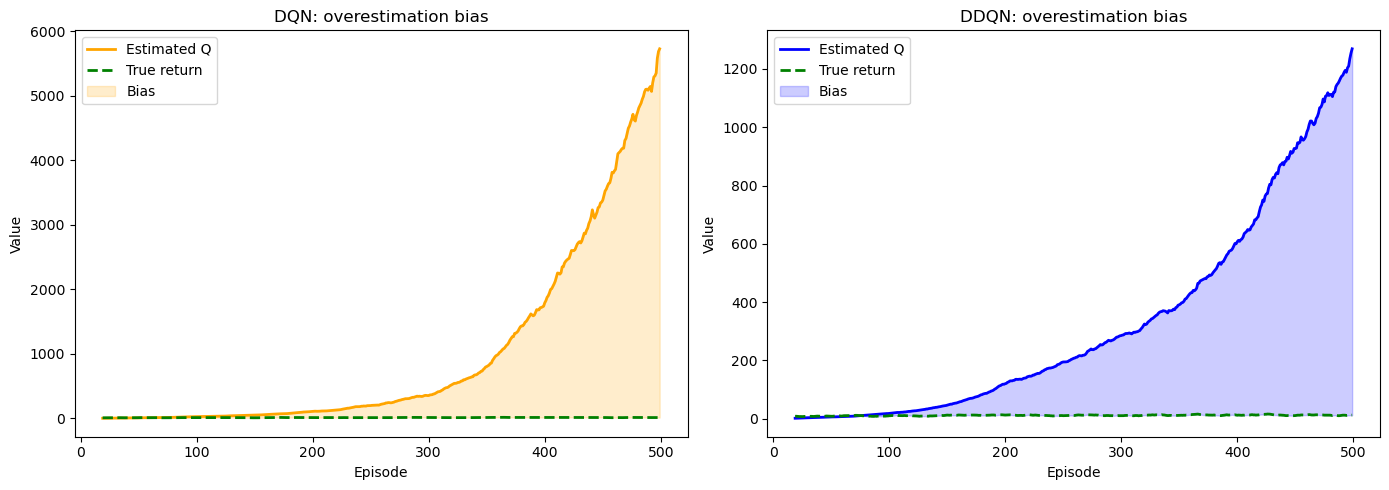

In [81]:
plot_bias(dqn_mean_q, dqn_true_returns, ddqn_mean_q, ddqn_true_returns)

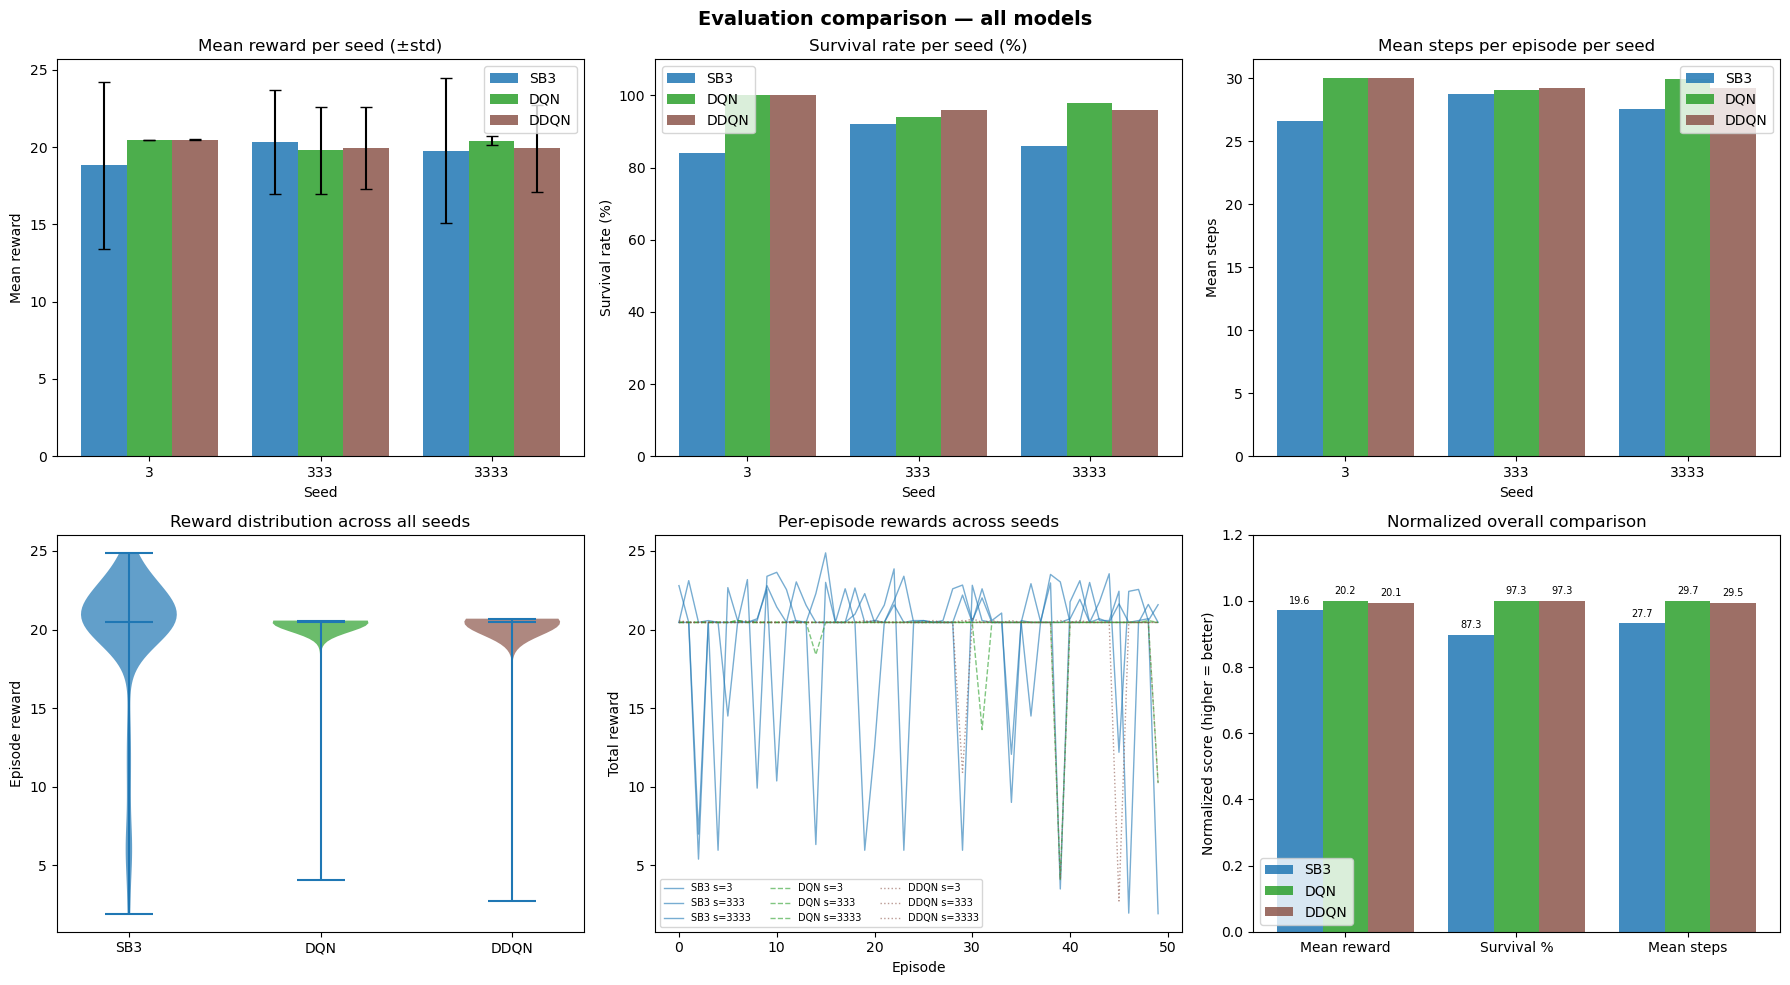

In [ ]:
def plot_evaluation_comparison(named_results):
    """
    named_results: list of (model_name, results) tuples
    e.g. [("SB3", sb3_results), ("DQN", dqn_results), ("DDQN", ddqn_results)]
    """
    def extract(results):
        seeds, means, stds, survivals, steps, all_rewards = [], [], [], [], [], []
        for seed, metrics, ep_rewards in results:
            seeds.append(seed)
            means.append(metrics['mean_reward'])
            stds.append(metrics['std_reward'])
            survivals.append(metrics['survival_rate'])
            steps.append(metrics['mean_steps'])
            all_rewards.extend(ep_rewards)
        return seeds, means, stds, survivals, steps, all_rewards

    extracted = {name: extract(results) for name, results in named_results}
    n_models  = len(named_results)
    names     = [name for name, _ in named_results]
    colors    = plt.cm.tab10(np.linspace(0, 0.5, n_models))

    seeds       = extracted[names[0]][0]
    seed_labels = [str(s) for s in seeds]
    x           = np.arange(len(seeds))
    width       = 0.8 / n_models

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- 1. Mean reward per seed ---
    ax = axes[0, 0]
    for i, (name, color) in enumerate(zip(names, colors)):
        _, means, stds, _, _, _ = extracted[name]
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, label=name, capsize=4, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(seed_labels)
    ax.set_title("Mean reward per seed (±std)")
    ax.set_xlabel("Seed"); ax.set_ylabel("Mean reward")
    ax.legend()

    # --- 2. Survival rate per seed ---
    ax = axes[0, 1]
    for i, (name, color) in enumerate(zip(names, colors)):
        _, _, _, survivals, _, _ = extracted[name]
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, survivals, width, label=name, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(seed_labels)
    ax.set_ylim(0, 110)
    ax.set_title("Survival rate per seed (%)")
    ax.set_xlabel("Seed"); ax.set_ylabel("Survival rate (%)")
    ax.legend()

    # --- 3. Mean steps per seed ---
    ax = axes[0, 2]
    for i, (name, color) in enumerate(zip(names, colors)):
        _, _, _, _, steps, _ = extracted[name]
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, steps, width, label=name, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(seed_labels)
    ax.set_title("Mean steps per episode per seed")
    ax.set_xlabel("Seed"); ax.set_ylabel("Mean steps")
    ax.legend()

    # --- 4. Reward distribution (violin) ---
    ax = axes[1, 0]
    all_rewards_list = [extracted[name][5] for name in names]
    parts = ax.violinplot(all_rewards_list, positions=range(1, n_models+1), showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    ax.set_xticks(range(1, n_models+1)); ax.set_xticklabels(names)
    ax.set_title("Reward distribution across all seeds")
    ax.set_ylabel("Episode reward")

    # --- 5. Per-episode rewards per seed ---
    ax = axes[1, 1]
    linestyles = ['-', '--', ':', '-.']
    for (name, results), color, ls in zip(named_results, colors, linestyles):
        for seed, _, ep_rewards in results:
            ax.plot(ep_rewards, color=color, alpha=0.6, linewidth=1,
                    linestyle=ls, label=f'{name} s={seed}')
    ax.set_title("Per-episode rewards across seeds")
    ax.set_xlabel("Episode"); ax.set_ylabel("Total reward")
    ax.legend(fontsize=7, ncol=n_models)

    # --- 6. Normalized overall comparison ---
    ax = axes[1, 2]
    metric_names  = ['Mean reward', 'Survival %', 'Mean steps']
    metric_values = {
        name: [
            np.mean(extracted[name][1]),  # mean reward
            np.mean(extracted[name][3]),  # survival
            np.mean(extracted[name][4]),  # steps
        ]
        for name in names
    }
    maxes = [max(metric_values[n][i] for n in names) or 1 for i in range(3)]
    xi = np.arange(len(metric_names))
    for i, (name, color) in enumerate(zip(names, colors)):
        offset   = (i - n_models/2 + 0.5) * width
        raw      = metric_values[name]
        normed   = [v/m for v, m in zip(raw, maxes)]
        bars = ax.bar(xi + offset, normed, width, label=name, color=color, alpha=0.85)
        for j, (bar, rv) in enumerate(zip(bars, raw)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{rv:.1f}", ha='center', fontsize=7)
    ax.set_xticks(xi); ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.2)
    ax.set_title("Normalized overall comparison")
    ax.set_ylabel("Normalized score (higher = better)")
    ax.legend()

    plt.suptitle("Evaluation comparison — all models", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



plot_evaluation_comparison([
    ("SB3",  sb3_results),
    ("DQN",  dqn_results),
    ("DDQN", ddqn_results),
])

In [93]:
def plot_eval_speed(all_seed_results):
    """Mean ego speed at each episode, one line per seed."""
    fig, ax = plt.subplots(figsize=(10, 4))
    for seed, metrics, _ in all_seed_results:
        speeds = metrics["episode_mean_speeds"]   # list of num_episodes floats
        ax.plot(speeds, alpha=0.7, label=f"Seed {seed}")
    ax.set_title("Mean ego speed per episode (evaluation)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Mean speed (m/s)")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_eval_action_distribution(all_seed_results):
    """Mean number of times each action was chosen per episode, averaged across seeds."""
    # Pool mean_action_counts across all seeds
    all_counts = np.array([m["mean_action_counts"] for _, m, _ in all_seed_results])
    pooled     = all_counts.mean(axis=0)   # shape (N_ACTIONS,)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        [ACTION_NAMES[a] for a in range(N_ACTIONS)],
        pooled,
        color=["steelblue", "seagreen", "tomato", "orange", "mediumpurple"]
    )
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_title("Mean number of times each action chosen per episode")
    ax.set_ylabel("Mean count per episode")
    plt.tight_layout()
    plt.show()

In [83]:
def build_and_save_results(named_results, save_path="./models/evaluation_results.csv"):
    rows = []
    for model_name, results in named_results:
        for seed, metrics, ep_rewards in results:
            rows.append({
                "model":         model_name,
                "seed":          seed,
                "mean_reward":   metrics["mean_reward"],
                "std_reward":    metrics["std_reward"],
                "min_reward":    metrics["min_reward"],
                "max_reward":    metrics["max_reward"],
                "mean_steps":    metrics["mean_steps"],
                "std_steps":     metrics["std_steps"],
                "min_steps":     metrics["min_steps"],
                "max_steps":     metrics["max_steps"],
                "n_crashes":     metrics["n_crashes"],
                "crash_rate":    metrics["crash_rate"],
                "survival_rate": metrics["survival_rate"],
            })

    df = pd.DataFrame(rows)

    # Summary rows (mean across seeds per model)
    summary = df.groupby("model").agg(
        overall_mean_reward  =("mean_reward",   "mean"),
        overall_std_reward   =("mean_reward",   "std"),
        overall_survival_rate=("survival_rate", "mean"),
        overall_mean_steps   =("mean_steps",    "mean"),
        overall_crash_rate   =("crash_rate",    "mean"),
    ).reset_index()

    df.to_csv(save_path, index=False)
    summary.to_csv(save_path.replace(".csv", "_summary.csv"), index=False)
    print(f"Saved to {save_path}")

    print("\nPer-seed results:")
    print(df.to_markdown(index=False))
    print("\nOverall summary:")
    print(summary.to_markdown(index=False))

    return df, summary


df, summary = build_and_save_results([
    ("DQN",  dqn_results),
    ("DDQN", ddqn_results),
    ("SB3", sb3_results)
])

Saved to ./models/evaluation_results.csv

Per-seed results:
| model   |   seed |   mean_reward |   std_reward |   min_reward |   max_reward |   mean_steps |   std_steps |   min_steps |   max_steps |   n_crashes |   crash_rate |   survival_rate |
|:--------|-------:|--------------:|-------------:|-------------:|-------------:|-------------:|------------:|------------:|------------:|------------:|-------------:|----------------:|
| DQN     |      3 |       20.4592 |    0.0229468 |     20.4545  |      20.5716 |        30    |     0       |          30 |          30 |           0 |            0 |             100 |
| DQN     |    333 |       19.7864 |    2.81613   |      4.09091 |      20.4545 |        29.08 |     3.90815 |           7 |          30 |           3 |            6 |              94 |
| DQN     |   3333 |       20.416  |    0.287166  |     18.4091  |      20.5716 |        29.96 |     0.28    |          28 |          30 |           1 |            2 |              98 |
| DDQN    

## 5. Enhanced DDQN

This section introduces an Enhanced DDQN that stacks **six targeted improvements** on top of the base DDQN.
Each one addresses a known weakness of the vanilla implementation in this environment:

| # | Improvement | What it fixes |
|---|-------------|---------------|
| 1 | **Dueling Network** | Separates *state value* V(s) from *action advantage* A(s,a). In highway-v0, many states are equally safe/unsafe regardless of action (clear road ahead); the network can learn V(s) without evaluating all actions. |
| 2 | **Prioritized Experience Replay (PER)** | Samples transitions proportional to their TD error. Crashes and near-misses — rare but critical — get replayed far more often than boring, redundant transitions. |
| 3 | **N-step returns** (n=3) | Accumulates reward over n steps before bootstrapping. Propagates the positive speed reward backwards faster, and connects crash penalties to the decisions that caused them. |
| 4 | **Huber loss** (SmoothL1) | Behaves like MSE for small TD errors, like MAE for large ones. Prevents large early errors from causing catastrophically large gradient updates. |
| 5 | **Soft target updates** (Polyak averaging) | Continuously blends the target network toward the online network (τ=0.005), rather than hard-copying every N steps. Much smoother optimization landscape. |
| 6 | **Gradient clipping** | Clips the gradient norm to 10 before each optimizer step. Prevents any single bad batch from destroying the weights. |

Together, improvements 1–3 are from the **Rainbow DQN** paper (Hessel et al., 2017); 4–6 are standard best practices.

In [84]:
class EnhancedCustomDDQNAgent:
    def __init__(self, action_space, observation_space, decrease_epsilon_factor=2000):
        self.action_space = action_space
        self.observation_space = observation_space
        self.learning_rate = 5e-4
        self.gamma = 0.99
        self.batch_size = 32
        self.buffer_capacity = 15000
        self.update_target_every = 50
        self.epsilon_start = 0.9
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon = self.epsilon_start
        self.grad_clip = 10.0              # ← NEW

        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128

        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.SmoothL1Loss()  # ← NEW: Huber loss instead of MSELoss

        self.n_steps = 0
        self.n_eps = 0

    def get_q(self, state):
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            return np.argmax(self.get_q(state))

    def decrease_epsilon(self):
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor))

    def update(self, state, action, reward, terminated, truncated, next_state):
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0),
            torch.tensor([[action]], dtype=torch.int64),
            torch.tensor([reward], dtype=torch.float32),
            torch.tensor([terminated], dtype=torch.int64),
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        if len(self.buffer) < self.batch_size:
            return np.inf, np.inf

        transitions = self.buffer.sample(self.batch_size)
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        q_values = self.q_net(state_batch).gather(1, action_batch)

        with torch.no_grad():
            next_state_indices_main = self.q_net(next_state_batch).argmax(dim=1, keepdim=True)
            next_state_values_target = self.target_net(next_state_batch).gather(1, next_state_indices_main).squeeze(1)
            next_state_values_target = next_state_values_target * (1 - terminated_batch)
            targets = reward_batch + (self.gamma * next_state_values_target)

        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), self.grad_clip)  # ← NEW
        self.optimizer.step()

        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.n_steps += 1
        if terminated or truncated:
            self.n_eps += 1
            self.decrease_epsilon()

        mean_max_q = self.q_net(state_batch).max(1)[0].detach().mean().item()
        return loss.item(), mean_max_q

In [85]:
N_EPISODES = 500
env = make_env()
enhanced_ddqn_agent = EnhancedCustomDDQNAgent(env.action_space, env.observation_space, 2000)
trained_enhanced_ddqn_agent, enhanced_ddqn_rewards, enhanced_ddqn_losses, enhanced_ddqn_lengths, enhanced_ddqn_epsilons, enhanced_ddqn_mean_q, enhanced_ddqn_true_returns = train_agent(enhanced_ddqn_agent, env, n_episodes=N_EPISODES)
file_path = "./models/500_trained_enhanced_ddqn_highway.pth"
torch.save(trained_enhanced_ddqn_agent.q_net.state_dict(), file_path)

np.save(f"./models/{N_EPISODES}_enhanced_ddqn_rewards.npy", enhanced_ddqn_rewards)
np.save(f"./models/{N_EPISODES}_enhanced_ddqn_losses.npy", enhanced_ddqn_losses)
np.save(f"./models/{N_EPISODES}_enhanced_ddqn_lengths.npy", enhanced_ddqn_lengths)
np.save(f"./models/{N_EPISODES}_enhanced_ddqn_epsilons.npy", enhanced_ddqn_epsilons)
np.save(f"./models/{N_EPISODES}_enhanced_ddqn_mean_q.npy", enhanced_ddqn_mean_q)
np.save(f"./models/{N_EPISODES}_enhanced_ddqn_true_returns.npy", enhanced_ddqn_true_returns)

Training agent: 100%|██████████| 500/500 [46:05<00:00,  5.53s/it]


In [86]:
enhanced_ddqn_results = evaluate_agent(trained_enhanced_ddqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [06:44<00:00,  8.09s/it]



Seed 3 — 50 episodes
  Reward     :  20.20 ± 2.58  [min: 2.16, max: 20.69]
  Steps      :   29.5 ± 3.6  [min: 4, max: 30]
  Crashes    : 1/50 (2.0% crash rate, 98.0% survival)



Evaluating Seed 333: 100%|██████████| 50/50 [06:33<00:00,  7.88s/it]



Seed 333 — 50 episodes
  Reward     :  19.73 ± 3.48  [min: 2.85, max: 21.53]
  Steps      :   28.8 ± 5.0  [min: 5, max: 30]
  Crashes    : 3/50 (6.0% crash rate, 94.0% survival)



Evaluating Seed 3333: 100%|██████████| 50/50 [06:39<00:00,  8.00s/it]


Seed 3333 — 50 episodes
  Reward     :  19.97 ± 3.21  [min: 1.48, max: 21.77]
  Steps      :   29.1 ± 4.5  [min: 3, max: 30]
  Crashes    : 2/50 (4.0% crash rate, 96.0% survival)


OVERALL (3 seeds)
  Mean reward    : 19.96 ± 0.19  (std is across seeds)
  Survival rate  : 96.0%
  Mean steps     : 29.1


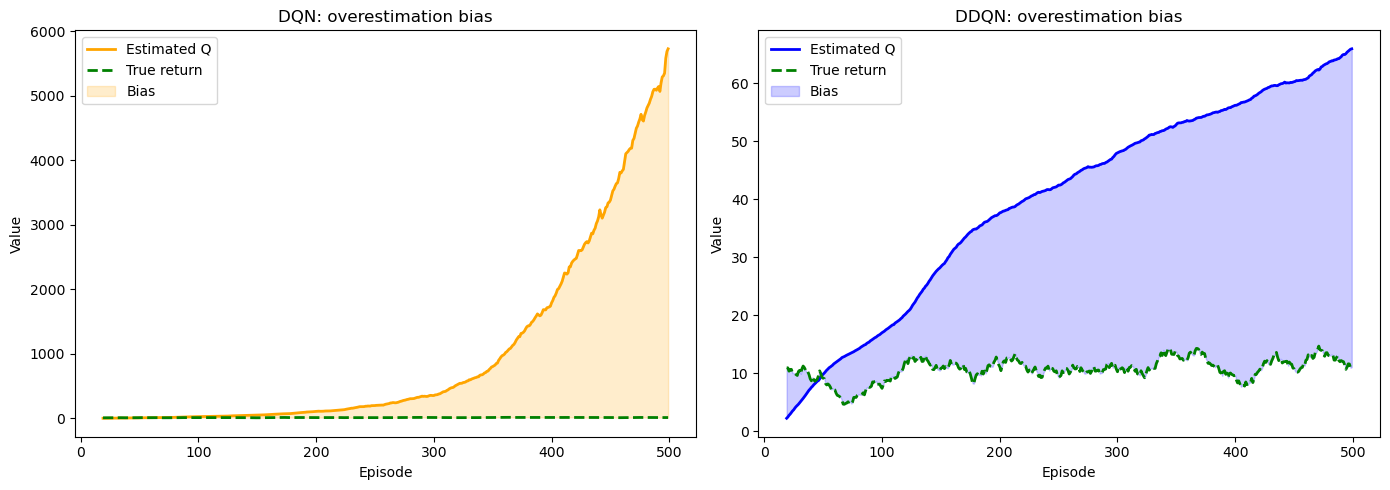

In [87]:
plot_bias(dqn_mean_q, dqn_true_returns, enhanced_ddqn_mean_q, enhanced_ddqn_true_returns)

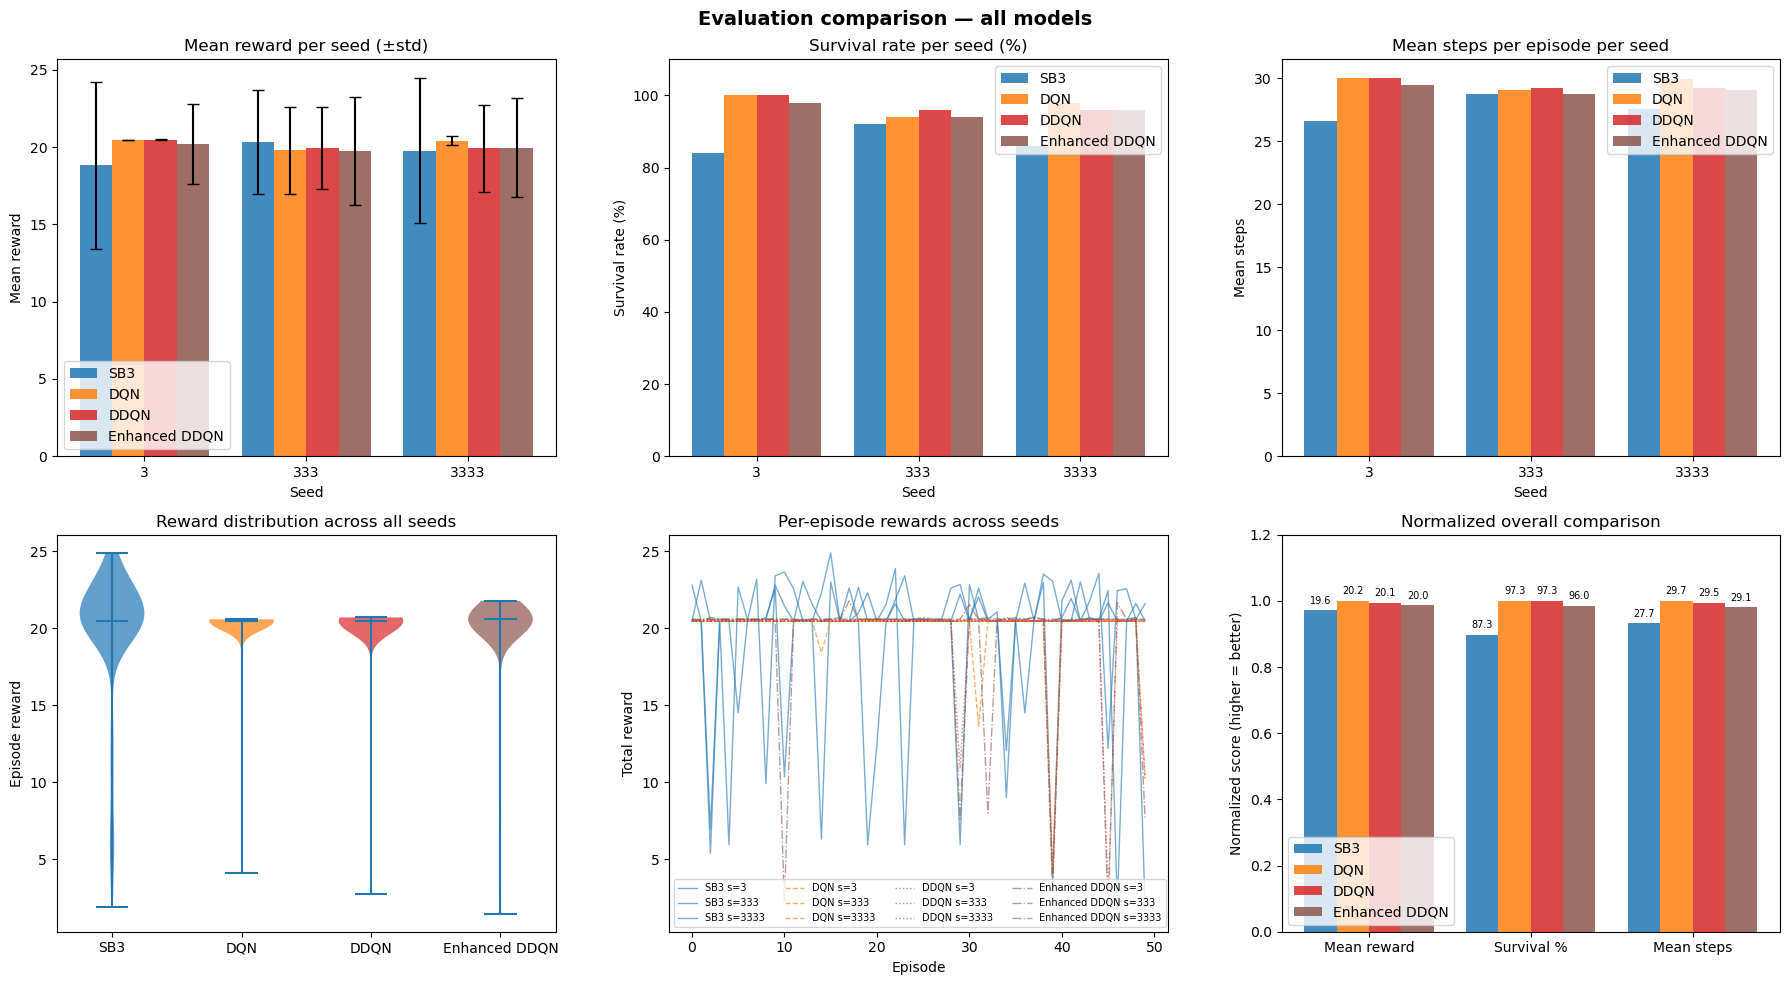

In [89]:
plot_evaluation_comparison([
    ("SB3",  sb3_results),
    ("DQN",  dqn_results),
    ("DDQN", ddqn_results),
    ("Enhanced DDQN", enhanced_ddqn_results)
])

## 6. Final DQN

In [ ]:
import random
from typing import Optional

import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state: np.ndarray, action: int, reward: float, terminated: bool, next_state: np.ndarray) -> None:
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size: int) -> list[tuple[Tensor, Tensor, Tensor, Tensor, Tensor]]:
        return random.choices(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)


class Net(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], hidden_size: int, n_actions: int):
        super(Net, self).__init__()

        in_features = int(np.prod(obs_shape))
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class HighwayDQN:
    def __init__(self,
                 env: gym.Env,
                 gamma: float,
                 batch_size: int,
                 buffer_capacity: int,
                 update_target_every: int,
                 epsilon_start: float,
                 decrease_epsilon_factor: float,
                 epsilon_min: float,
                 learning_rate: float,
                 model_type: str = "DDQN"):

        self.env = env
        self.action_space = env.action_space
        self.observation_space = env.observation_space
        self.gamma = gamma

        self.batch_size = batch_size
        self.buffer_capacity = buffer_capacity
        self.update_target_every = update_target_every

        self.epsilon_start = epsilon_start
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon_min = epsilon_min

        self.learning_rate = learning_rate
        self.device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
        self.model_type = model_type 
        print(f"Initializing DQN on device: {self.device}")

        self.reset()

    def reset(self):
        hidden_size = 64

        obs_shape = self.observation_space.shape
        n_actions = int(self.action_space.n)

        self.buffer = ReplayBuffer(self.buffer_capacity)
        self.q_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
        self.target_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.loss_function = nn.MSELoss()
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)

        self.epsilon = self.epsilon_start
        self.n_steps = 0
        self.n_eps = 0

    def get_q(self, state: np.ndarray) -> np.ndarray:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net(state_tensor)
        return output.cpu().numpy()[0]

    def decrease_epsilon(self):
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_steps / self.decrease_epsilon_factor) )

    def get_action(self, state: np.ndarray, epsilon: Optional[float] = None) -> int:
        if epsilon is None:
            epsilon = self.epsilon

        if np.random.rand() < epsilon:  # type: ignore
            return self.action_space.sample()

        return int(np.argmax(self.get_q(state)))

    def update(self, state: np.ndarray, action: int, reward: float,
            terminated: bool, truncated: bool, next_state: np.ndarray) -> tuple:  # added truncated
        self.buffer.push(state, action, reward, terminated, next_state)
        if len(self.buffer) < self.batch_size:
            self.n_steps += 1
            return np.inf, np.inf  
        
        transitions = self.buffer.sample(self.batch_size)
        states, actions, rewards, terminateds, next_states = zip(*transitions)

        states_t = torch.as_tensor(np.array(states), dtype=torch.float32,  device=self.device)
        actions_t = torch.as_tensor(actions, dtype=torch.int64,    device=self.device).unsqueeze(1)
        rewards_t = torch.as_tensor(rewards, dtype=torch.float32,  device=self.device)
        terminateds_t = torch.as_tensor(terminateds, dtype=torch.float32,  device=self.device)
        next_states_t = torch.as_tensor(np.array(next_states), dtype=torch.float32,  device=self.device)

        values = self.q_net(states_t).gather(1, actions_t)
        with torch.no_grad():
            if self.model_type == "DDQN":
                next_state_actions = self.q_net.forward(next_states_t).argmax(dim=1).unsqueeze(1)
                next_q_values = self.target_net.forward(next_states_t).gather(1, next_state_actions).squeeze(1)
            else:
                next_q_values = self.target_net.forward(next_states_t).max(1)[0]
            targets = rewards_t + self.gamma * next_q_values * (1 - terminateds_t)

        loss = self.loss_function(values, targets.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if not ((self.n_steps + 1) % self.update_target_every):
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.decrease_epsilon()
        self.n_steps += 1

        mean_max_q = self.q_net(states_t).max(1)[0].detach().mean().item()
        return loss.detach().item(), mean_max_q 

    def save(self, filepath: str):
        """Saves the Q-network's weights to a file."""
        torch.save(self.q_net.state_dict(), filepath)

    def load(self, filepath: str):
        """Loads the Q-network's weights from a file."""
        self.q_net.load_state_dict(torch.load(filepath, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

## Improved DDQN

In [6]:
import random
from typing import Optional
from collections import deque

import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state: np.ndarray, action: int, reward: float, terminated: bool, next_state: np.ndarray) -> None:
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size: int) -> list[tuple[Tensor, Tensor, Tensor, Tensor, Tensor]]:
        return random.choices(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)
    
class SumTree:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)   # internal nodes + leaves
        self.data = np.zeros(capacity, dtype=object)
        self.size = 0
        self.position = 0

    def _propagate(self, idx: int, delta: float) -> None:
        """Propagate priority changes to the root"""
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def _retrieve(self, idx: int, v: float) -> int:
        """Go down the tree to find the leaf corresponding to v"""
        left  = 2 * idx + 1
        right = 2 * idx + 2
        if left >= len(self.tree):
            return idx
        if v <= self.tree[left]:
            return self._retrieve(left, v)
        else:
            return self._retrieve(right, v - self.tree[left])

    @property
    def total(self) -> float:
        return self.tree[0]

    def add(self, priority: float, data: tuple) -> None:
        idx = self.position + self.capacity - 1
        self.data[self.position] = data
        self.update(idx, priority)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, idx: int, priority: float) -> None:
        delta = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, delta)

    def get(self, v: float) -> tuple[int, float, tuple]:
        """Return (idx_tree, priority, transition)."""
        v = min(v, self.tree[0] - 1e-6)  # clamp to avoid empty leaves
        idx = self._retrieve(0, v)
        data_idx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[data_idx]

    def __len__(self):
        return self.size


class PERBuffer:
    def __init__(self, capacity: int, alpha: float = 0.6,
                 beta_start: float = 0.4, beta_frames: int = 100_000,
                 epsilon: float = 1e-6):
        self.tree = SumTree(capacity)
        self.alpha = alpha          # priority exponent (0 = uniform, 1 = full priority)
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.epsilon = epsilon      # minimal priority to avoid p = 0
        self.frame = 0

    def _priority(self, error: float) -> float:
        return (abs(error) + self.epsilon) ** self.alpha

    @property
    def beta(self) -> float:
        """beta increase linearly between beta_start and 1"""
        return min(1.0, self.beta_start + self.frame * (1.0 - self.beta_start) / self.beta_frames)

    def push(self, state, action, reward, terminated, next_state, error: float = 1.0) -> None:
        """New transitions get existing maximal priority"""
        if self.tree.size == 0:
            max_priority = self._priority(1.0)  # arbitrary initial priority
        else:
            max_priority = self.tree.tree[self.tree.capacity - 1:
                                        self.tree.capacity - 1 + self.tree.size].max()
        self.tree.add(max_priority, (state, action, reward, terminated, next_state))

    def sample(self, batch_size: int) -> tuple:
        """Return transitions, indices and IS weights"""
        indices, priorities, transitions = [], [], []
        segment = self.tree.total / batch_size

        self.frame += batch_size

        for i in range(batch_size):
            v = random.uniform(segment * i, segment * (i + 1))
            idx, priority, transition = self.tree.get(v)
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)

        # importance sampling weight
        probs = np.array(priorities) / self.tree.total
        weights = (len(self.tree) * probs) ** (-self.beta)
        weights /= weights.max()   # normalisation for numeric stability

        return transitions, indices, torch.tensor(weights, dtype=torch.float32)

    def update_priorities(self, indices: list[int], errors: np.ndarray) -> None:
        for idx, error in zip(indices, errors):
            self.tree.update(idx, self._priority(error))

    def __len__(self):
        return len(self.tree)


class Net(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], hidden_size: int, n_actions: int):
        super(Net, self).__init__()

        in_features = int(np.prod(obs_shape))
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)
    

class DuelingNet(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], hidden_size: int, n_actions: int):
        super(DuelingNet, self).__init__()

        in_features = int(np.prod(obs_shape))

        # shared layer
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        # value stream : one scalar V(s)
        self.value_stream = nn.Linear(hidden_size, 1)

        # advantage stream : one value per action A(s, a)
        self.advantage_stream = nn.Linear(hidden_size, n_actions)

    def forward(self, x: Tensor):
        shared = self.shared(x)

        value = self.value_stream(shared)           # (batch, 1)
        advantage = self.advantage_stream(shared)   # (batch, n_actions)

        q = value + advantage - advantage.mean(dim=1, keepdim=True)

        return q # (batch, n_actions)



class ImprovedHighwayDQN:
    def __init__(self,
                 env: gym.Env,
                 gamma: float,
                 batch_size: int,
                 buffer_capacity: int,
                 epsilon_start: float,
                 decrease_epsilon_factor: float,
                 epsilon_min: float,
                 learning_rate: float,
                 model_type: str = "DDQN",
                 tau: float = 0.005, # for soft update of target network
                 gradient_clip: float = 10.0,
                 use_DuelingNet: bool = True, # to choose between Net and DuelingNet
                 use_nstep: bool = True, # to choose wether to use n_Step returns or not
                 nstep: int = 3, #number of steps to aggregate (default : 3)
                 use_PER : bool = True, # to choose wether to use PER buffer of classical buffer
                 per_alpha: float = 0.6,
                 per_beta_start: float = 0.4,
                 per_beta_frames: int = 45000, # to adjust to the expected number of frames for training (e.g. n_episodes * mean_episode_length)
                 ):

        self.env = env
        self.action_space = env.action_space
        self.observation_space = env.observation_space
        self.gamma = gamma

        self.batch_size = batch_size
        self.buffer_capacity = buffer_capacity
        self.tau = tau

        self.epsilon_start = epsilon_start
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon_min = epsilon_min

        self.learning_rate = learning_rate
        self.device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
        self.model_type = model_type
        self.gradient_clip = gradient_clip
        print(f"Initializing DQN on device: {self.device}")

        self.use_DuelingNet = use_DuelingNet

        self.use_nstep = use_nstep
        self.nstep = nstep
        self.gamma_n = gamma ** nstep

        self.use_per = use_PER
        self.per_alpha = per_alpha
        self.per_beta_start = per_beta_start
        self.per_beta_frames = per_beta_frames

        self.reset()

    def reset(self):
        hidden_size = 64

        obs_shape = self.observation_space.shape
        n_actions = int(self.action_space.n)
        if self.use_per:
            self.buffer = PERBuffer(self.buffer_capacity, self.per_alpha, self.per_beta_start, self.per_beta_frames)
        else:
            self.buffer = ReplayBuffer(self.buffer_capacity)

        if self.use_DuelingNet:
            self.q_net = DuelingNet(obs_shape, hidden_size, n_actions).to(self.device)
            self.target_net = DuelingNet(obs_shape, hidden_size, n_actions).to(self.device)
        else:
            self.q_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
            self.target_net = Net(obs_shape, hidden_size, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        # Improvement 4 : Use Huber Loss instead of MSELoss for better stability
        self.loss_function = nn.SmoothL1Loss(beta=1.0) # Equivalent to Huber loss with delta=1.0
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)

        self.epsilon = self.epsilon_start
        self.n_steps = 0
        self.n_eps = 0
        if self.use_nstep:
            self.n_step_buffer = deque(maxlen=self.nstep)

    def get_q(self, state: np.ndarray) -> np.ndarray:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net(state_tensor)
        return output.cpu().numpy()[0]

    def decrease_epsilon(self):
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_steps / self.decrease_epsilon_factor) )
        
    def _compute_n_step_transition(self) -> tuple:
        """
        Compute N-step transition from temporary buffer
        Return (s_0, a_0, G, terminated, s_n).
        """
        state, action = self.n_step_buffer[0][:2]

        G = 0.0
        for i, (_, _, reward, terminated, _) in enumerate(self.n_step_buffer):
            G += (self.gamma ** i) * reward
            if terminated:
                # No bootstrapping if the episode ends before N-steps
                return state, action, G, True, self.n_step_buffer[i][4]

        # Bootstrapping from s_n
        next_state = self.n_step_buffer[-1][4]
        return state, action, G, False, next_state

    def get_action(self, state: np.ndarray, epsilon: Optional[float] = None) -> int:
        if epsilon is None:
            epsilon = self.epsilon

        if np.random.rand() < epsilon:  # type: ignore
            return self.action_space.sample()

        return int(np.argmax(self.get_q(state)))
    
    

    def update(self, state: np.ndarray, action: int, reward: float,
            terminated: bool, truncated: bool, next_state: np.ndarray) -> tuple:  # added truncated
        
        if self.use_nstep:
            self.n_step_buffer.append((state, action, reward, terminated, next_state))
            if len(self.n_step_buffer) < self.nstep:
                self.n_steps += 1
                return np.inf, np.inf
            self.buffer.push(*self._compute_n_step_transition())
        else:
            self.buffer.push(state, action, reward, terminated, next_state)

        return self._gradient_step()


    def _gradient_step(self) -> tuple:
        """Extracted this part to be used on the remaining steps of the nstep_buffer at the end of an episode
           so the crashing steps are not lost"""
        if len(self.buffer) < self.batch_size:
            self.n_steps += 1
            return np.inf, np.inf  
        
        if self.use_per:
            transitions, per_indices, is_weights = self.buffer.sample(self.batch_size)
            is_weights = is_weights.to(self.device)
        else:
            transitions = self.buffer.sample(self.batch_size)

        states, actions, rewards, terminateds, next_states = zip(*transitions)

        states_t = torch.as_tensor(np.array(states), dtype=torch.float32,  device=self.device)
        actions_t = torch.as_tensor(actions, dtype=torch.int64,    device=self.device).unsqueeze(1)
        rewards_t = torch.as_tensor(rewards, dtype=torch.float32,  device=self.device)
        terminateds_t = torch.as_tensor(terminateds, dtype=torch.float32,  device=self.device)
        next_states_t = torch.as_tensor(np.array(next_states), dtype=torch.float32,  device=self.device)

        values = self.q_net(states_t).gather(1, actions_t)

        with torch.no_grad():
            if self.model_type == "DDQN":
                next_state_actions = self.q_net.forward(next_states_t).argmax(dim=1).unsqueeze(1)
                next_q_values = self.target_net.forward(next_states_t).gather(1, next_state_actions).squeeze(1)
            else:
                next_q_values = self.target_net.forward(next_states_t).max(1)[0]

            gamma = self.gamma_n if self.use_nstep else self.gamma
            targets = rewards_t + gamma * next_q_values * (1 - terminateds_t)

        # TD errors to update priorities
        td_errors = (targets.unsqueeze(1) - values).detach().abs().cpu().numpy().flatten()

        # Loss : ponderated by IS if we use PER
        if self.use_per:
            element_loss = nn.SmoothL1Loss(reduction='none')(values, targets.unsqueeze(1))
            loss = (element_loss.squeeze(1) * is_weights).mean()
            self.buffer.update_priorities(per_indices, td_errors)
        else:
            loss = self.loss_function(values, targets.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()

        # Improvement 6 : Clip gradients to prevent exploding gradients and improve stability
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=self.gradient_clip)

        self.optimizer.step()

        # Improvement 5 : Use soft update for target network instead of hard update every N steps for smoother learning
        with torch.no_grad():
            for target_param, param in zip(self.target_net.parameters(), self.q_net.parameters()):
                target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

        self.decrease_epsilon()
        self.n_steps += 1

        mean_max_q = self.q_net(states_t).max(1)[0].detach().mean().item()
        return loss.detach().item(), mean_max_q 

    def save(self, filepath: str):
        """Saves the Q-network's weights to a file."""
        torch.save(self.q_net.state_dict(), filepath)

    def load(self, filepath: str):
        """Loads the Q-network's weights from a file."""
        self.q_net.load_state_dict(torch.load(filepath, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

We need to flush the n_step_buffer when an episode ends in the training loop : 

In [9]:
def train_agent(agent, env, n_episodes=500):
    episode_rewards, episode_losses, episode_lengths, epsilon_history = [], [], [], []
    episode_mean_q, episode_true_returns = [], []

    for episode in tqdm(range(n_episodes), desc="Training agent"):
        state, _ = env.reset()
        done = False
        total_reward, step_count = 0, 0
        ep_losses, ep_q_values, ep_rewards = [], [], []

        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            result = agent.update(state, action, reward, terminated, truncated, next_state)
            if result[0] != np.inf:
                ep_losses.append(result[0])

            # Compute Q on the ACTUAL current state, not a random batch
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(agent.device)
                q_val = agent.q_net(state_tensor).max(1)[0].item()
            ep_q_values.append(q_val)         
            ep_rewards.append(reward)
            state = next_state
            total_reward += reward
            step_count += 1

        # Flushing the nstep_buffer when an episode ends
        if agent.use_nstep:
            while len(agent.n_step_buffer) > 0:
                agent.buffer.push(*agent._compute_n_step_transition())
                result = agent._gradient_step()
                if result[0] != np.inf:
                    ep_losses.append(result[0])
                agent.n_step_buffer.popleft()
                

        # True discounted return from t=0
        true_return = 0
        for r in reversed(ep_rewards):
            true_return = r + agent.gamma * true_return

        episode_rewards.append(total_reward)
        episode_lengths.append(step_count)
        epsilon_history.append(agent.epsilon)
        episode_true_returns.append(true_return)                         
        episode_mean_q.append(np.mean(ep_q_values) if ep_q_values else 0) 
        episode_losses.append(np.mean(ep_losses) if ep_losses else 0.0)

    return agent, episode_rewards, episode_losses, episode_lengths, epsilon_history, episode_mean_q, episode_true_returns

In [24]:
N_EPISODES = 1500
env = make_env()
rainbowDQN_noPER = ImprovedHighwayDQN(env=env, gamma=0.99, batch_size=32, buffer_capacity=15000, epsilon_start=0.9, decrease_epsilon_factor=6000, 
                                      epsilon_min=0.05, learning_rate = 5e-4, model_type="DDQN", tau=0.005, gradient_clip=10.0,
                                      use_DuelingNet=True, use_nstep=True, nstep=3, use_PER=False)
trained_rainbowDQN_noPER, rainbowDQN_noPER_rewards, rainbowDQN_noPER_losses, rainbowDQN_noPER_lengths, rainbowDQN_noPER_epsilons, rainbowDQN_noPER_mean_q, rainbowDQN_noPER_true_returns = train_agent(rainbowDQN_noPER, env, n_episodes=N_EPISODES)
file_path = "./models/1500_trained_rainbowDQN_noPER_highway.pth"
torch.save(trained_rainbowDQN_noPER.q_net.state_dict(), file_path)

np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_rewards.npy", rainbowDQN_noPER_rewards)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_losses.npy", rainbowDQN_noPER_losses)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_lengths.npy", rainbowDQN_noPER_lengths)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_epsilons.npy", rainbowDQN_noPER_epsilons)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_mean_q.npy", rainbowDQN_noPER_mean_q)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_true_returns.npy", rainbowDQN_noPER_true_returns)

Initializing DQN on device: cpu


Training agent: 100%|██████████| 1500/1500 [3:20:29<00:00,  8.02s/it]  


In [25]:
rainbowDQN_noPER_results = evaluate_agent(trained_rainbowDQN_noPER, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [03:29<00:00,  4.20s/it]



Seed 3 — 50 episodes
  Reward     :  10.21 ± 6.66  [min: 0.99, max: 25.62]
  Steps      :   11.9 ± 7.8  [min: 2, max: 30]
  Crashes    : 49/50 (98.0% crash rate, 2.0% survival)
  Mean speed : 27.63 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   0.1 steps
    IDLE        :   6.7 steps
    LANE_RIGHT  :   0.0 steps
    FASTER      :   4.8 steps
    SLOWER      :   0.1 steps



Evaluating Seed 333: 100%|██████████| 50/50 [03:11<00:00,  3.83s/it]



Seed 333 — 50 episodes
  Reward     :   9.13 ± 6.27  [min: 0.97, max: 27.02]
  Steps      :   10.6 ± 6.8  [min: 2, max: 30]
  Crashes    : 48/50 (96.0% crash rate, 4.0% survival)
  Mean speed : 27.46 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   0.3 steps
    IDLE        :   5.3 steps
    LANE_RIGHT  :   0.0 steps
    FASTER      :   4.8 steps
    SLOWER      :   0.2 steps



Evaluating Seed 3333: 100%|██████████| 50/50 [03:14<00:00,  3.89s/it]


Seed 3333 — 50 episodes
  Reward     :   9.27 ± 5.97  [min: 0.86, max: 26.22]
  Steps      :   10.8 ± 6.8  [min: 2, max: 30]
  Crashes    : 48/50 (96.0% crash rate, 4.0% survival)
  Mean speed : 27.57 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   0.3 steps
    IDLE        :   5.5 steps
    LANE_RIGHT  :   0.0 steps
    FASTER      :   4.9 steps
    SLOWER      :   0.1 steps


OVERALL (3 seeds)
  Mean reward    : 9.54 ± 0.48  (std is across seeds)
  Survival rate  : 3.3%
  Mean steps     : 11.1
  Mean speed     : 27.55 m/s


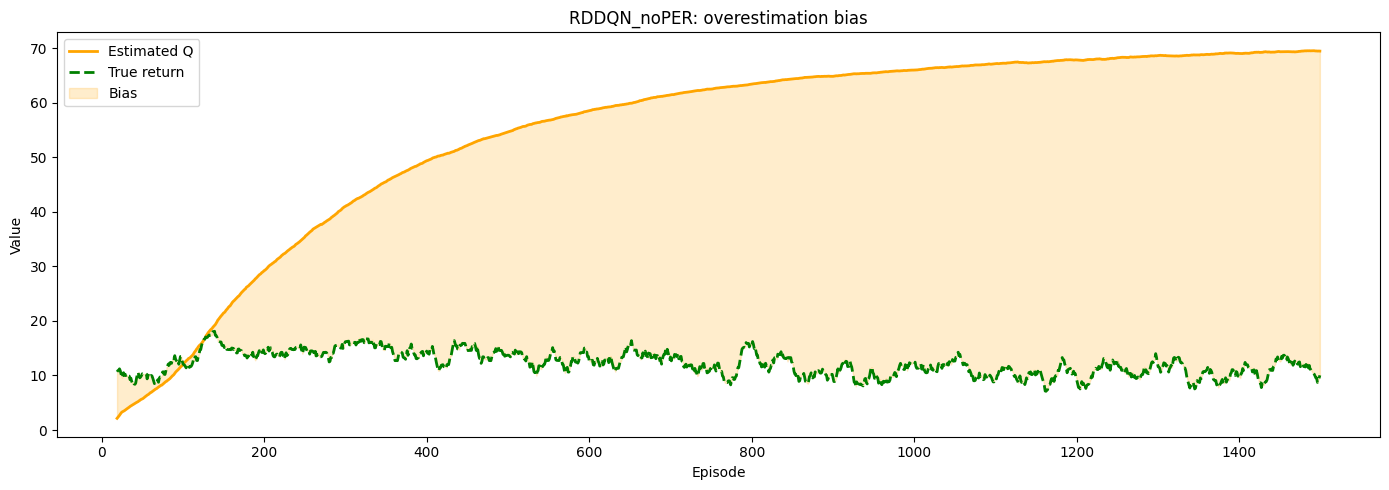

In [31]:
window = 20
fig = plt.figure(figsize=(14, 5))
smooth = lambda x: np.convolve(x, np.ones(window)/window, mode='valid')
x = range(window - 1, len(rainbowDQN_noPER_mean_q))


sq, sr = smooth(rainbowDQN_noPER_mean_q), smooth(rainbowDQN_noPER_true_returns)
plt.plot(x, sq, color="orange",   linewidth=2, label="Estimated Q")
plt.plot(x, sr, color="green", linewidth=2, linestyle="--", label="True return")
plt.fill_between(x, sr, sq, alpha=0.2, color="orange", label="Bias")
plt.title("RDDQN_noPER: overestimation bias")
plt.xlabel("Episode")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

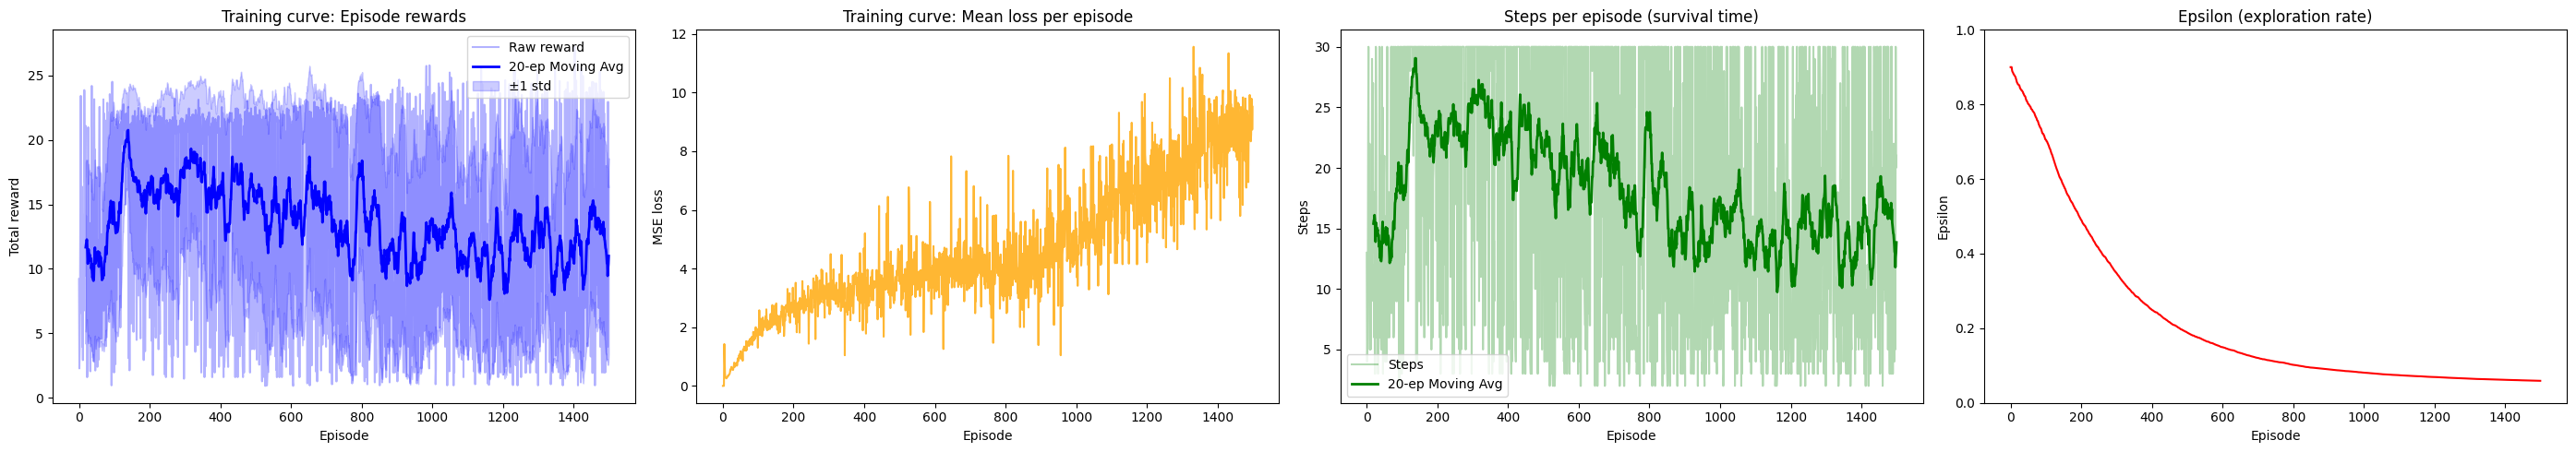

In [33]:
plot_training_curves(rainbowDQN_noPER_rewards, rainbowDQN_noPER_losses, rainbowDQN_noPER_lengths, rainbowDQN_noPER_epsilons)

In [11]:
N_EPISODES = 1000
env = make_env()
rainbowDQN_noPER = ImprovedHighwayDQN(env=env, gamma=0.99, batch_size=32, buffer_capacity=15000, epsilon_start=0.9, decrease_epsilon_factor=6000, 
                                      epsilon_min=0.05, learning_rate = 5e-4, model_type="DDQN", tau=0.005, gradient_clip=10.0,
                                      use_DuelingNet=True, use_nstep=True, nstep=3, use_PER=False)
trained_rainbowDQN_noPER_1000, rainbowDQN_noPER_rewards_1000, rainbowDQN_noPER_losses_1000, rainbowDQN_noPER_lengths_1000, rainbowDQN_noPER_epsilons_1000, rainbowDQN_noPER_mean_q_1000, rainbowDQN_noPER_true_returns_1000 = train_agent(rainbowDQN_noPER, env, n_episodes=N_EPISODES)
file_path = "./models/1500_trained_rainbowDQN_noPER_highway.pth"
torch.save(trained_rainbowDQN_noPER_1000.q_net.state_dict(), file_path)

np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_rewards.npy", rainbowDQN_noPER_rewards_1000)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_losses.npy", rainbowDQN_noPER_losses_1000)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_lengths.npy", rainbowDQN_noPER_lengths_1000)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_epsilons.npy", rainbowDQN_noPER_epsilons_1000)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_mean_q.npy", rainbowDQN_noPER_mean_q_1000)
np.save(f"./models/{N_EPISODES}_rainbowDQN_noPER_true_returns.npy", rainbowDQN_noPER_true_returns_1000)

Initializing DQN on device: cpu


Training agent: 100%|██████████| 1000/1000 [3:24:01<00:00, 12.24s/it] 


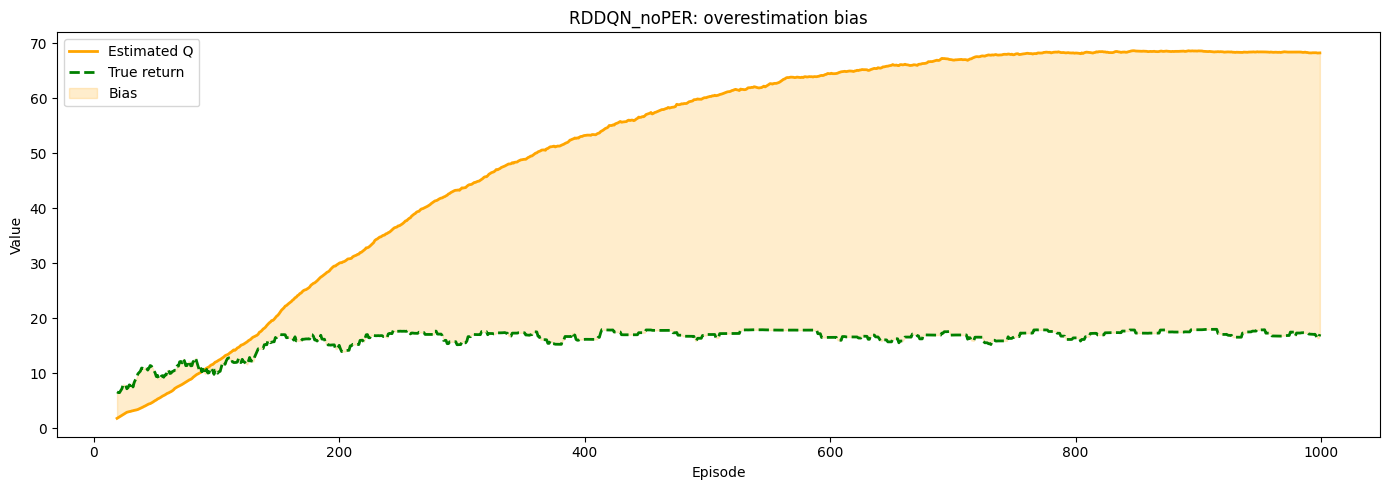

In [12]:
window = 20
fig = plt.figure(figsize=(14, 5))
smooth = lambda x: np.convolve(x, np.ones(window)/window, mode='valid')
x = range(window - 1, len(rainbowDQN_noPER_mean_q_1000))


sq, sr = smooth(rainbowDQN_noPER_mean_q_1000), smooth(rainbowDQN_noPER_true_returns_1000)
plt.plot(x, sq, color="orange",   linewidth=2, label="Estimated Q")
plt.plot(x, sr, color="green", linewidth=2, linestyle="--", label="True return")
plt.fill_between(x, sr, sq, alpha=0.2, color="orange", label="Bias")
plt.title("RDDQN_noPER: overestimation bias")
plt.xlabel("Episode")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

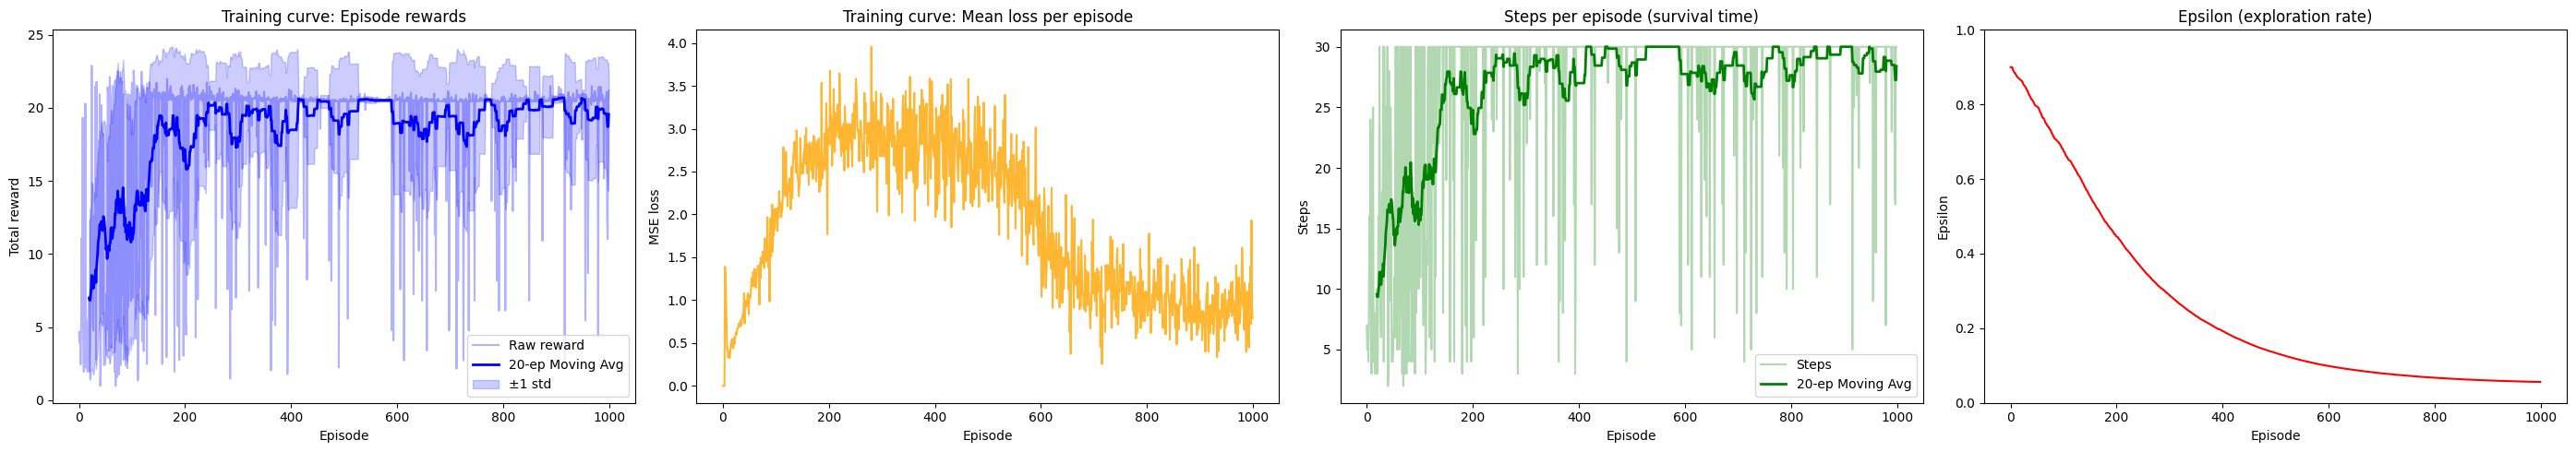

In [13]:
plot_training_curves(rainbowDQN_noPER_rewards_1000, rainbowDQN_noPER_losses_1000, rainbowDQN_noPER_lengths_1000, rainbowDQN_noPER_epsilons_1000)

In [14]:
rainbowDQN_noPER_results = evaluate_agent(trained_rainbowDQN_noPER_1000, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [09:02<00:00, 10.85s/it]



Seed 3 — 50 episodes
  Reward     :  20.01 ± 2.82  [min: 2.13, max: 21.08]
  Steps      :   29.2 ± 3.9  [min: 4, max: 30]
  Crashes    : 3/50 (6.0% crash rate, 94.0% survival)
  Mean speed : 20.34 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :   9.6 steps
    IDLE        :   9.2 steps
    LANE_RIGHT  :   1.0 steps
    FASTER      :   1.8 steps
    SLOWER      :   7.6 steps



Evaluating Seed 333: 100%|██████████| 50/50 [09:24<00:00, 11.29s/it]



Seed 333 — 50 episodes
  Reward     :  20.40 ± 1.22  [min: 12.44, max: 21.42]
  Steps      :   29.7 ± 1.6  [min: 19, max: 30]
  Crashes    : 2/50 (4.0% crash rate, 96.0% survival)
  Mean speed : 20.33 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :  11.7 steps
    IDLE        :   7.5 steps
    LANE_RIGHT  :   1.2 steps
    FASTER      :   1.8 steps
    SLOWER      :   7.5 steps



Evaluating Seed 3333: 100%|██████████| 50/50 [09:06<00:00, 10.92s/it]


Seed 3333 — 50 episodes
  Reward     :  20.00 ± 2.99  [min: 3.41, max: 21.07]
  Steps      :   29.2 ± 4.2  [min: 6, max: 30]
  Crashes    : 2/50 (4.0% crash rate, 96.0% survival)
  Mean speed : 20.28 m/s
  Action breakdown (mean counts/episode):
    LANE_LEFT   :  10.7 steps
    IDLE        :   7.6 steps
    LANE_RIGHT  :   1.4 steps
    FASTER      :   1.7 steps
    SLOWER      :   7.8 steps


OVERALL (3 seeds)
  Mean reward    : 20.14 ± 0.19  (std is across seeds)
  Survival rate  : 95.3%
  Mean steps     : 29.4
  Mean speed     : 20.32 m/s
